<h1 style = "color : white; background-color: red"> 30000 Spotify Songs Analysis </h1>

Ce projet objectif est d'analyser statistiquement le jeu de données "30000 Spotify Songs" sur KAGGLE <a href = "https://www.kaggle.com/datasets/joebeachcapital/30000-spotify-songs"> Disponible d'ici </a>

In [29]:
## Mettre l'introduction d'ici

# I. Donnée exploration 

In [138]:
#Charger les bibliothèques nécessaires
library(ggplot2)
library(tidyverse)
library(gridExtra)
library(GGally)
library(plotly)
library(corrplot)
library(reshape2)
library(FactoMineR) 
library(factoextra)
library(glmnet) 
library(ggfortify)
library(pROC)
library(ROCR)
library(dplyr)
library(corrplot)
library(MASS)
library(ggrepel)
library(scales)
library(cluster)
library(dendextend)
library(kernlab)
library(dbscan)
library(mclust)


Package 'mclust' version 6.1
Type 'citation("mclust")' for citing this R package in publications.


Attaching package: 'mclust'


The following object is masked from 'package:purrr':

    map




In [31]:
#Charger les données
path <- ""
df <- read.csv(paste(path, "spotify_songs.csv", sep = ""),
                    sep = ",", header = TRUE)

In [32]:
summary(df)

   track_id          track_name        track_artist       track_popularity
 Length:32833       Length:32833       Length:32833       Min.   :  0.00  
 Class :character   Class :character   Class :character   1st Qu.: 24.00  
 Mode  :character   Mode  :character   Mode  :character   Median : 45.00  
                                                          Mean   : 42.48  
                                                          3rd Qu.: 62.00  
                                                          Max.   :100.00  
 track_album_id     track_album_name   track_album_release_date
 Length:32833       Length:32833       Length:32833            
 Class :character   Class :character   Class :character        
 Mode  :character   Mode  :character   Mode  :character        
                                                               
                                                               
                                                               
 playlist_name      playlis

In [33]:
#Ajouter des variables temporelles
df$year <- as.factor(as.numeric(substr(df$track_album_release_date, 1, 3))*10)
df$month <- as.factor(substr(df$track_album_release_date, 6, 7))
df$quarter <- factor(df$month,
  levels = c("01","02","03","04","05","06","07","08","09","10","11","12"),
  labels = c("Quarter 1","Quarter 1","Quarter 1", 
             "Quarter 2","Quarter 2","Quarter 2",
             "Quarter 3","Quarter 3","Quarter 3",
             "Quarter 4","Quarter 4","Quarter 4")
)

In [34]:
#Séparer les variables numériques et catégorielles pour les analyses ultérieures
df[, c('playlist_genre', 'playlist_subgenre', 'mode', 'key')] <- 
  lapply(df[, c('playlist_genre', 'playlist_subgenre', 'mode', 'key')], as.factor)
num_df <- df %>% dplyr :: select(where(is.numeric)) %>% na.omit() %>% distinct()
cat_df <- df %>% dplyr::select(where(is.factor))

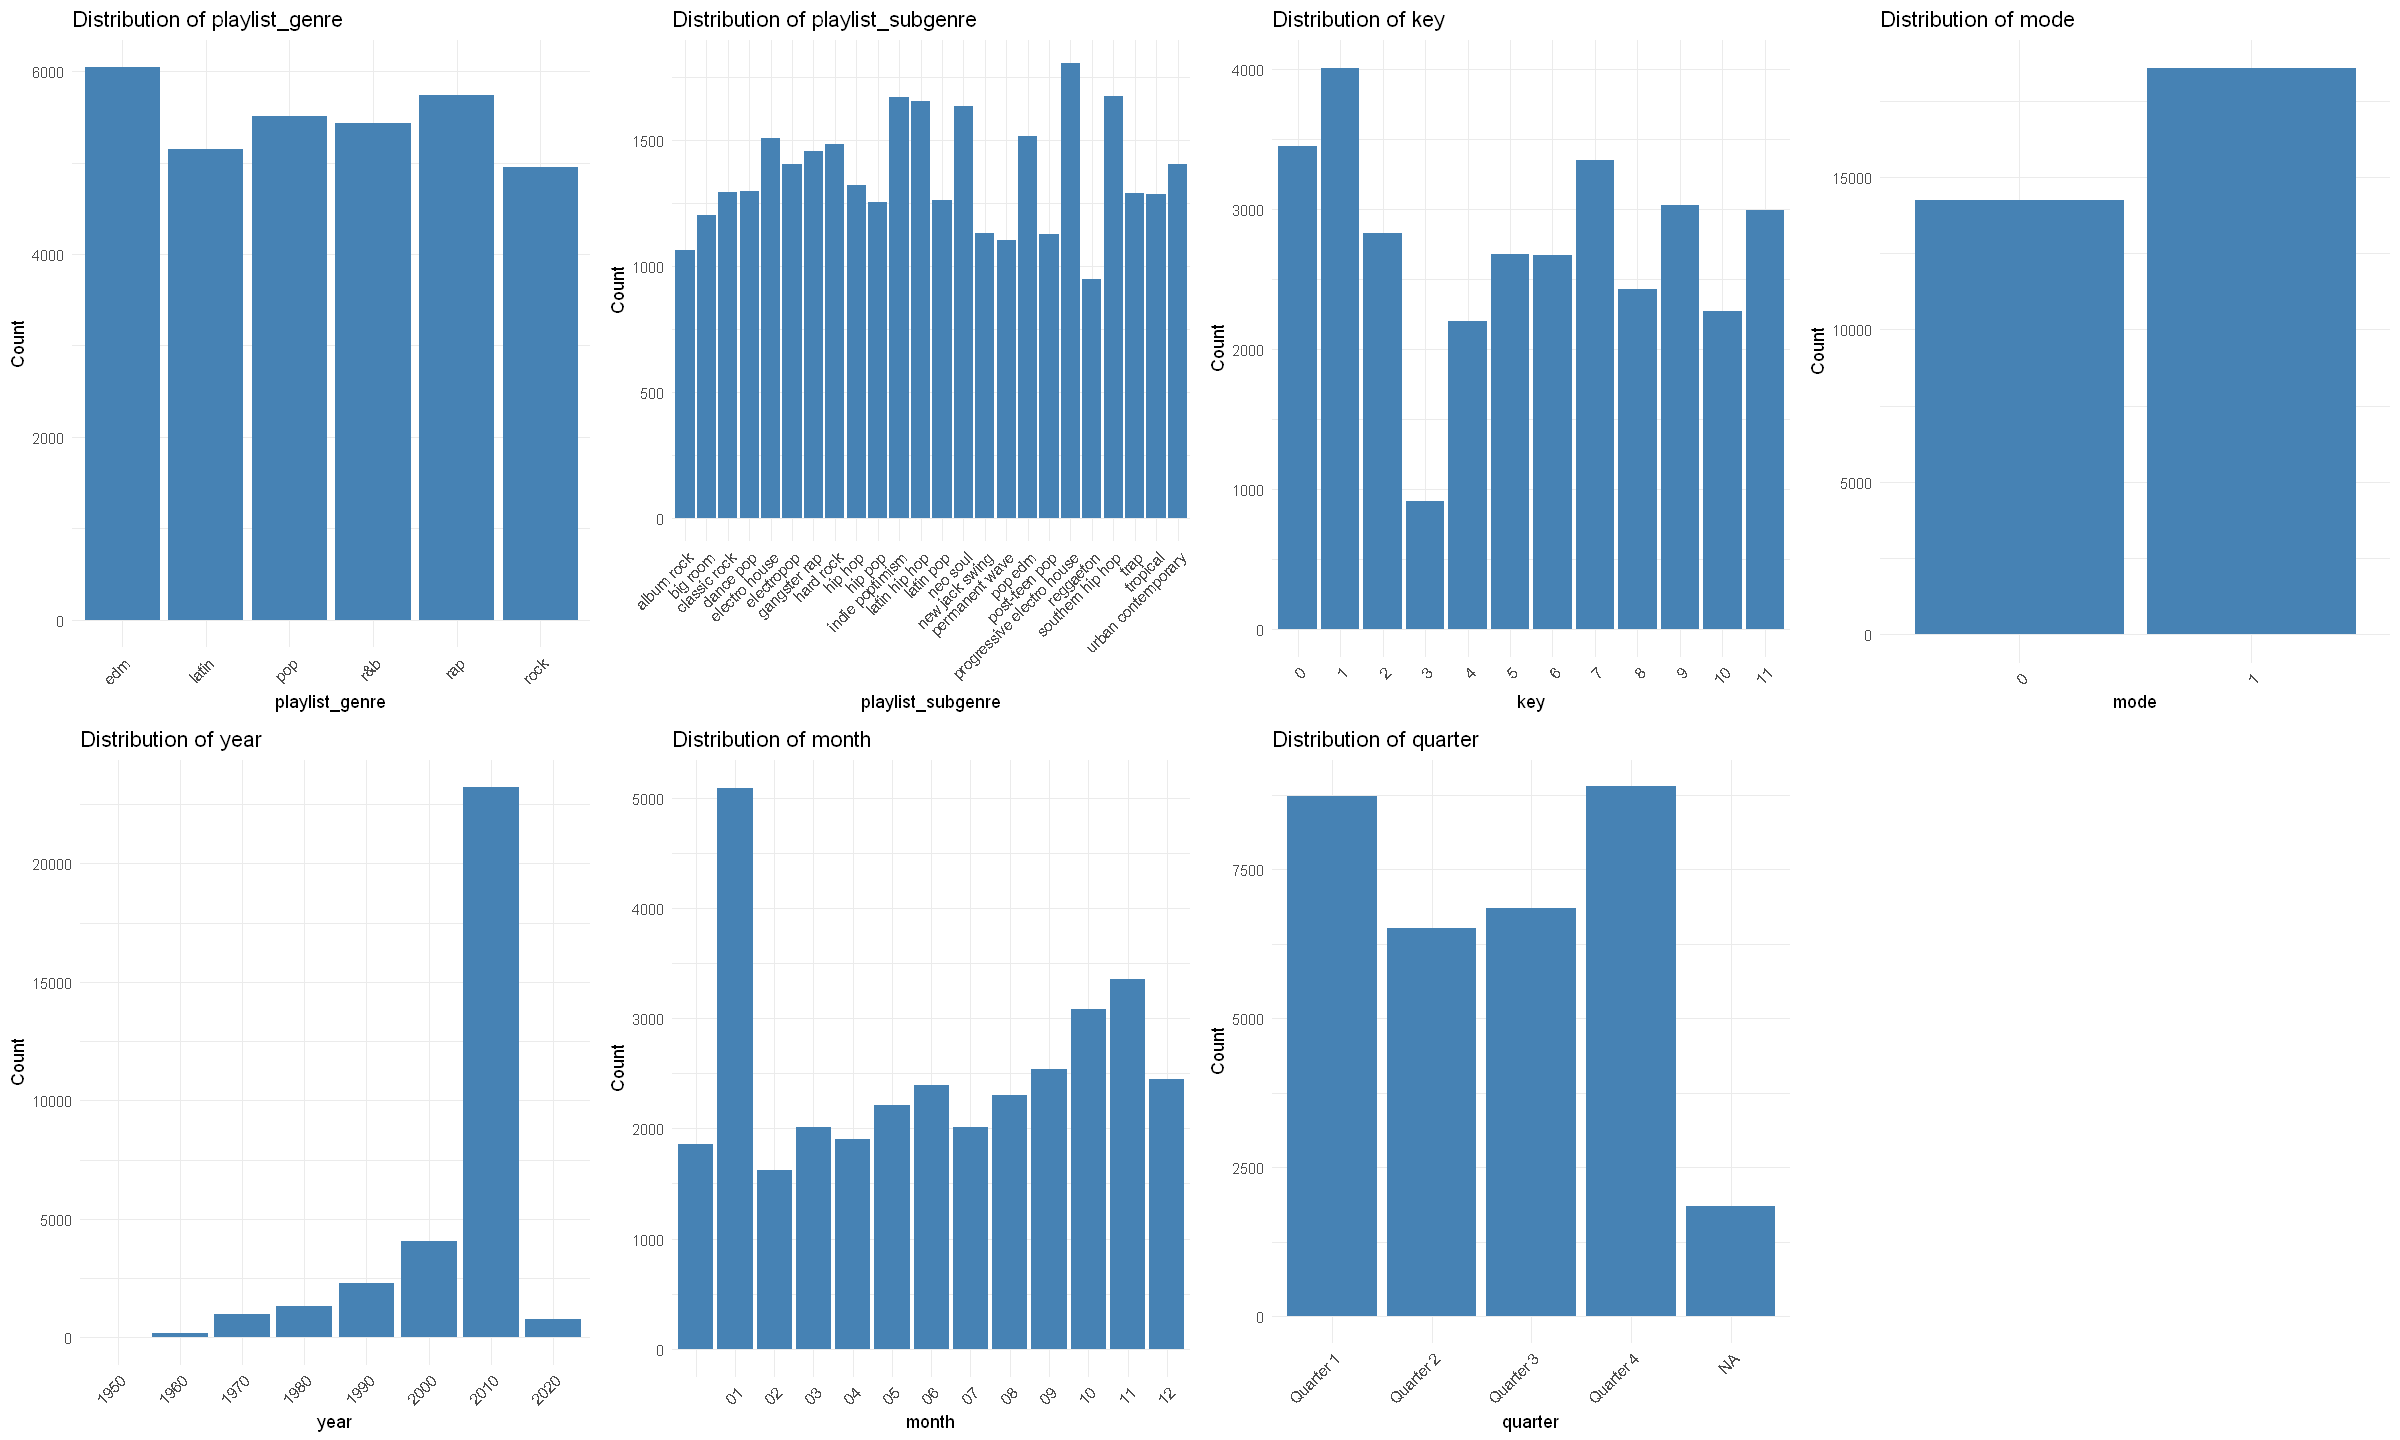

In [35]:
# Visualiser les distributions des variables catégorielles
plot_list <- list()

for (col in names(cat_df)) {
  plot_list[[col]] <- ggplot(cat_df, aes(x = .data[[col]])) +
    geom_bar(fill = "steelblue") +
    labs(x = col, y = "Count",
         title = paste("Distribution of", col)) +
    theme_minimal() +
    theme(axis.text.x = element_text(angle = 45, hjust = 1))
   
} 
options(repr.plot.width = 20, repr.plot.height = 12)
do.call(grid.arrange, c(plot_list, ncol = 4, nrow = 2))

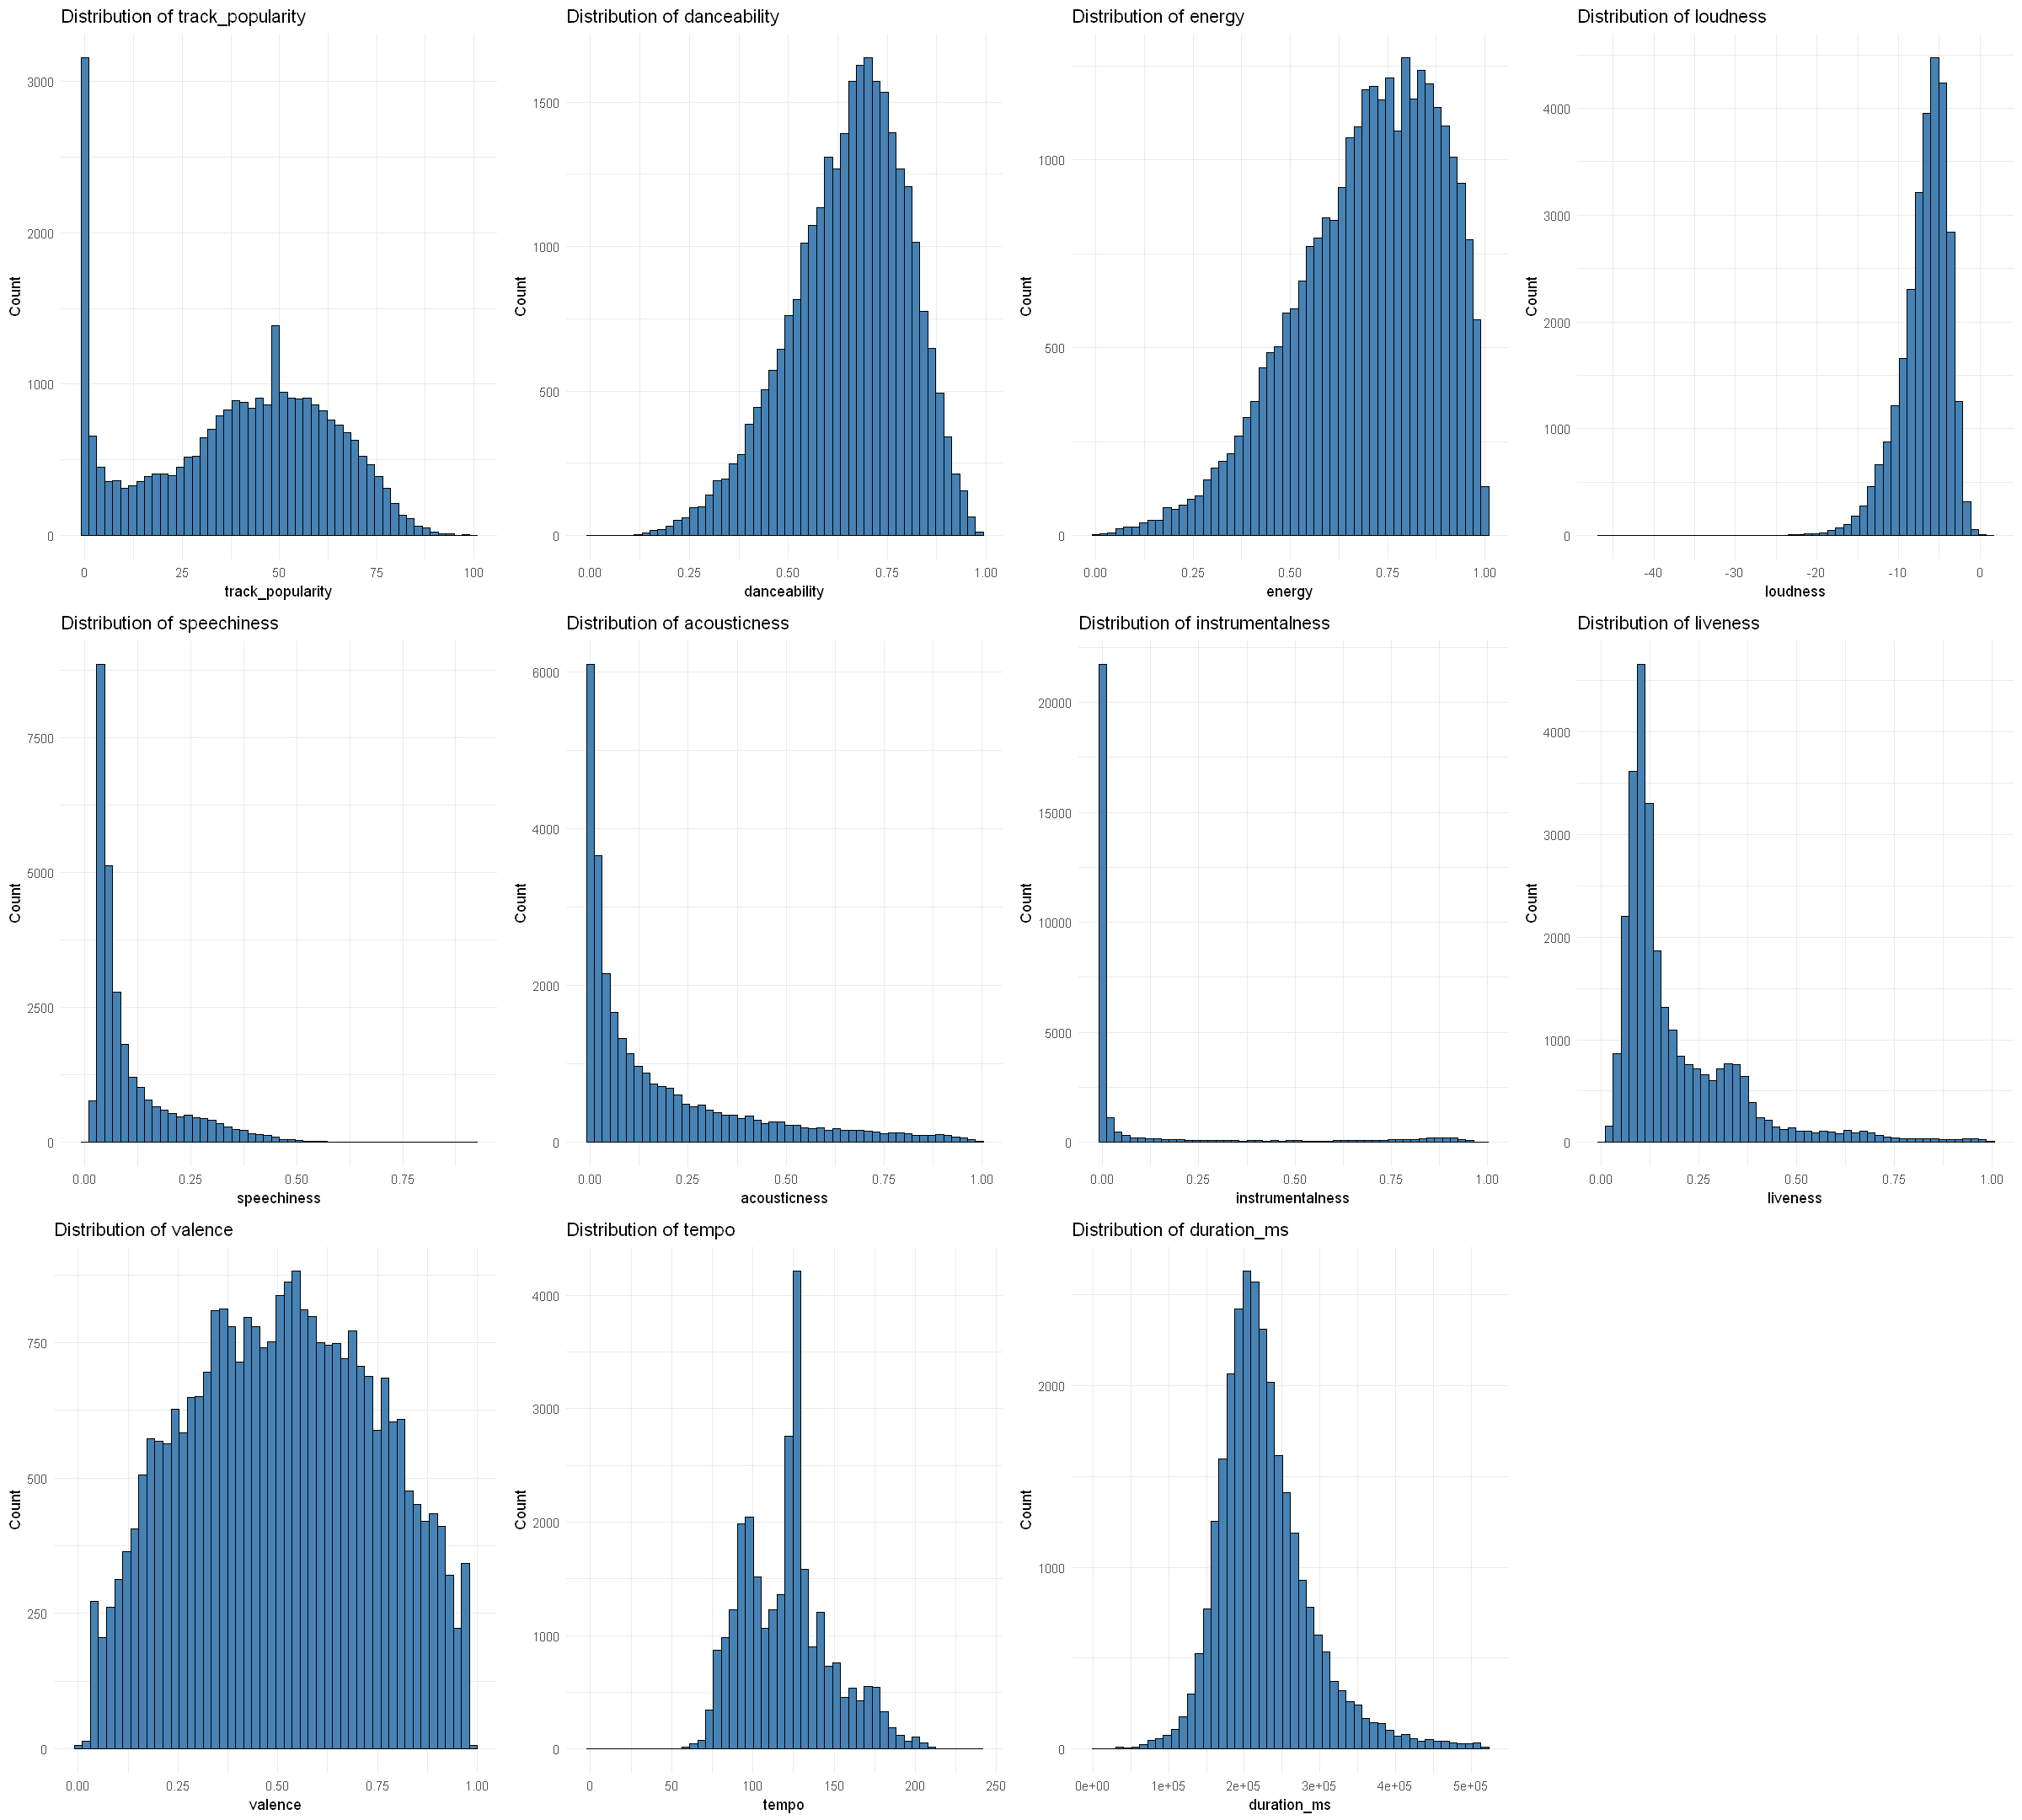

In [36]:
#Visualiser les distributions des variables numériques
plot_list <- list()
for (col in names(num_df)) {
  plot_list[[col]] <- ggplot(num_df, aes(x = .data[[col]])) +
    geom_histogram(bins = 50, fill = "steelblue", color = "black") +
    labs(x = col, y = "Count",
         title = paste("Distribution of", col)) +
    theme_minimal()
}
options(repr.plot.width = 20, repr.plot.height = 18)
do.call(grid.arrange, c(plot_list, ncol = 4, nrow = 3))

In [37]:
# Calculer le skewness pour la transformation ultérieure
library(moments)
for (col in names(num_df)) {
  skewness_value <- skewness(num_df[[col]], na.rm = TRUE)
  cat("Skewness of", col, ":", skewness_value, "\n")
}

Skewness of track_popularity : -0.2315432 
Skewness of danceability : -0.5060617 
Skewness of energy : -0.6455868 
Skewness of loudness : -1.358801 
Skewness of speechiness : 1.965565 
Skewness of acousticness : 1.575693 
Skewness of instrumentalness : 2.627647 
Skewness of liveness : 2.081978 
Skewness of valence : -0.007881982 
Skewness of tempo : 0.5138545 
Skewness of duration_ms : 1.115681 


In [46]:
# Transformation à variable factorielle
cat_df$factor_popularity <- ceiling(df$track_popularity/10)
cat_df$factor_popularity <- as.factor(cat_df$factor_popularity)
df$factor_popularity <- ceiling(df$track_popularity/10)
df$factor_popularity <- as.factor(df$factor_popularity)
cat_df$bool_instrumentalness <- ifelse(df$instrumentalness == 0, "Zero", "Non-Zero")
df$bool_instrumentalness <- ifelse(df$instrumentalness == 0, "Zero", "Non-Zero")
options(repr.plot.width = 8, repr.plot.height = 6)


In [40]:
#Transformation des variables numériques pour réduire le skewness
num_df$sqrt_speechiness <- sqrt(num_df$speechiness)
num_df$sqrt_acousticness <- sqrt(num_df$acousticness)
num_df$sqrt_duration_ms <- sqrt(num_df$duration_ms)
num_df$log_liveness <- log(num_df$liveness + 1)
num_df$cqrt_loudness <- sign(num_df$loudness) * abs(num_df$loudness)^(1/3)
df$sqrt_speechiness <- sqrt(df$speechiness)
df$sqrt_acousticness <- sqrt(df$acousticness)
df$sqrt_duration_ms <- sqrt(df$duration_ms)
df$log_liveness <- log(df$liveness + 1)
df$cqrt_loudness <- sign(df$loudness) * abs(df$loudness)^(1/3)
df <- df %>% dplyr::select(-c(speechiness, acousticness, duration_ms, liveness, loudness))
num_df %>% dplyr :: select(-c(speechiness, acousticness, duration_ms, liveness, instrumentalness,loudness)) -> num_df

In [47]:
#Faire une ANOVA pour chaque variable numérique en fonction de chaque variable catégorielle
num_vars <- names(num_df)
cat_vars <- names(cat_df)
pval_matrix <- matrix(NA, nrow = length(num_vars), ncol = length(cat_vars),
                      dimnames = list(num_vars, cat_vars))
for (cat_col in cat_vars) {
    for (num_col in num_vars){
        formula <- as.formula(paste(num_col, "~", cat_col))
        model <- lm(formula, data = df)
        df.aov <- anova(model)
        pval_matrix[num_col, cat_col] <- df.aov$`Pr(>F)`[1]
    }
}
pval_df <- as.data.frame(pval_matrix)
print(pval_df)

                  playlist_genre playlist_subgenre          key         mode
track_popularity   2.702657e-218      0.000000e+00 1.988223e-05 5.394028e-02
danceability        0.000000e+00      0.000000e+00 8.403977e-74 2.035418e-26
energy              0.000000e+00      0.000000e+00 4.047891e-12 3.844765e-01
valence             0.000000e+00      0.000000e+00 2.944886e-16 6.356985e-01
tempo              3.272718e-147     9.858056e-220 1.290336e-05 9.419525e-03
sqrt_speechiness    0.000000e+00      0.000000e+00 4.888261e-80 7.165962e-40
sqrt_acousticness   0.000000e+00      0.000000e+00 2.897930e-30 8.151056e-01
sqrt_duration_ms   1.949270e-311      0.000000e+00 1.182305e-16 5.086051e-03
log_liveness        5.991555e-56      2.282519e-97 1.334488e-15 2.790239e-01
cqrt_loudness       0.000000e+00      0.000000e+00 1.320625e-19 9.095210e-04
                           year         month      quarter factor_popularity
track_popularity  1.711428e-141  7.462157e-64 2.364186e-47      0.000000e+00

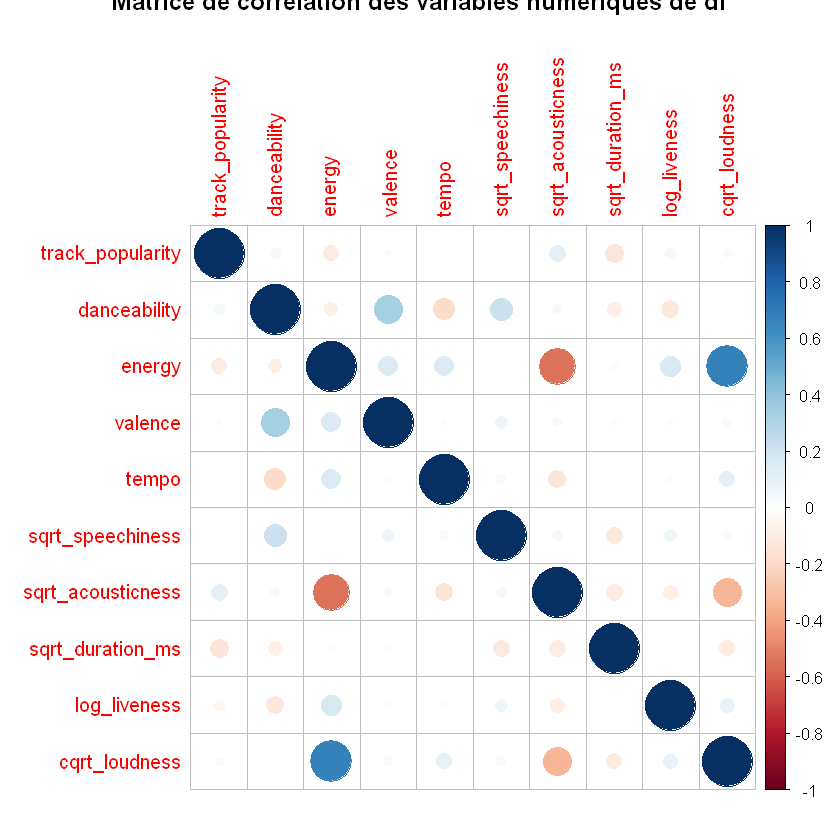

In [ ]:
corrplot(cor(num_df), title = "Matrice de corrélation des variables numériques de df")

In [ ]:
#Khi-deux test pour chaque paire de variables catégorielles
results <- data.frame()

for (i in 1:(ncol(cat_df) - 1)) {
  for (j in (i + 1):ncol(cat_df)) {
    test <- chisq.test(table(cat_df[[i]], cat_df[[j]]))
    
    results <- rbind(results, data.frame(
      var1    = names(cat_df)[i],
      var2    = names(cat_df)[j],
      chi_sq  = round(test$statistic, 3),
      p_value = test$p.value
    ))
  }
}
print(results)

Warning message in chisq.test(table(cat_df[[i]], cat_df[[j]])):
"Chi-squared approximation may be incorrect"
Warning message in chisq.test(table(cat_df[[i]], cat_df[[j]])):
"Chi-squared approximation may be incorrect"
Warning message in chisq.test(table(cat_df[[i]], cat_df[[j]])):
"Chi-squared approximation may be incorrect"
Warning message in chisq.test(table(cat_df[[i]], cat_df[[j]])):
"Chi-squared approximation may be incorrect"
Warning message in chisq.test(table(cat_df[[i]], cat_df[[j]])):
"Chi-squared approximation may be incorrect"
Warning message in chisq.test(table(cat_df[[i]], cat_df[[j]])):
"Chi-squared approximation may be incorrect"
Warning message in chisq.test(table(cat_df[[i]], cat_df[[j]])):
"Chi-squared approximation may be incorrect"
Warning message in chisq.test(table(cat_df[[i]], cat_df[[j]])):
"Chi-squared approximation may be incorrect"


                         var1                  var2     chi_sq       p_value
X-squared      playlist_genre     playlist_subgenre 164165.000  0.000000e+00
X-squared1     playlist_genre                   key    943.906 3.957663e-162
X-squared2     playlist_genre                  mode    516.795 1.891477e-109
X-squared3     playlist_genre                  year  12000.737  0.000000e+00
X-squared4     playlist_genre                 month   1836.393  0.000000e+00
X-squared5     playlist_genre               quarter    231.407  8.223388e-41
X-squared6     playlist_genre bool_instrumentalness   2496.988  0.000000e+00
X-squared7  playlist_subgenre                   key   1445.238 5.269916e-166
X-squared8  playlist_subgenre                  mode    758.696 1.852956e-145
X-squared9  playlist_subgenre                  year  20934.367  0.000000e+00
X-squared10 playlist_subgenre                 month   3795.826  0.000000e+00
X-squared11 playlist_subgenre               quarter   1040.380 2.522739e-173

# II. Réduction dimensionelle

## 1. ACP

In [ ]:
#ACP
df.acp <- PCA(num_df,scale.unit = TRUE)

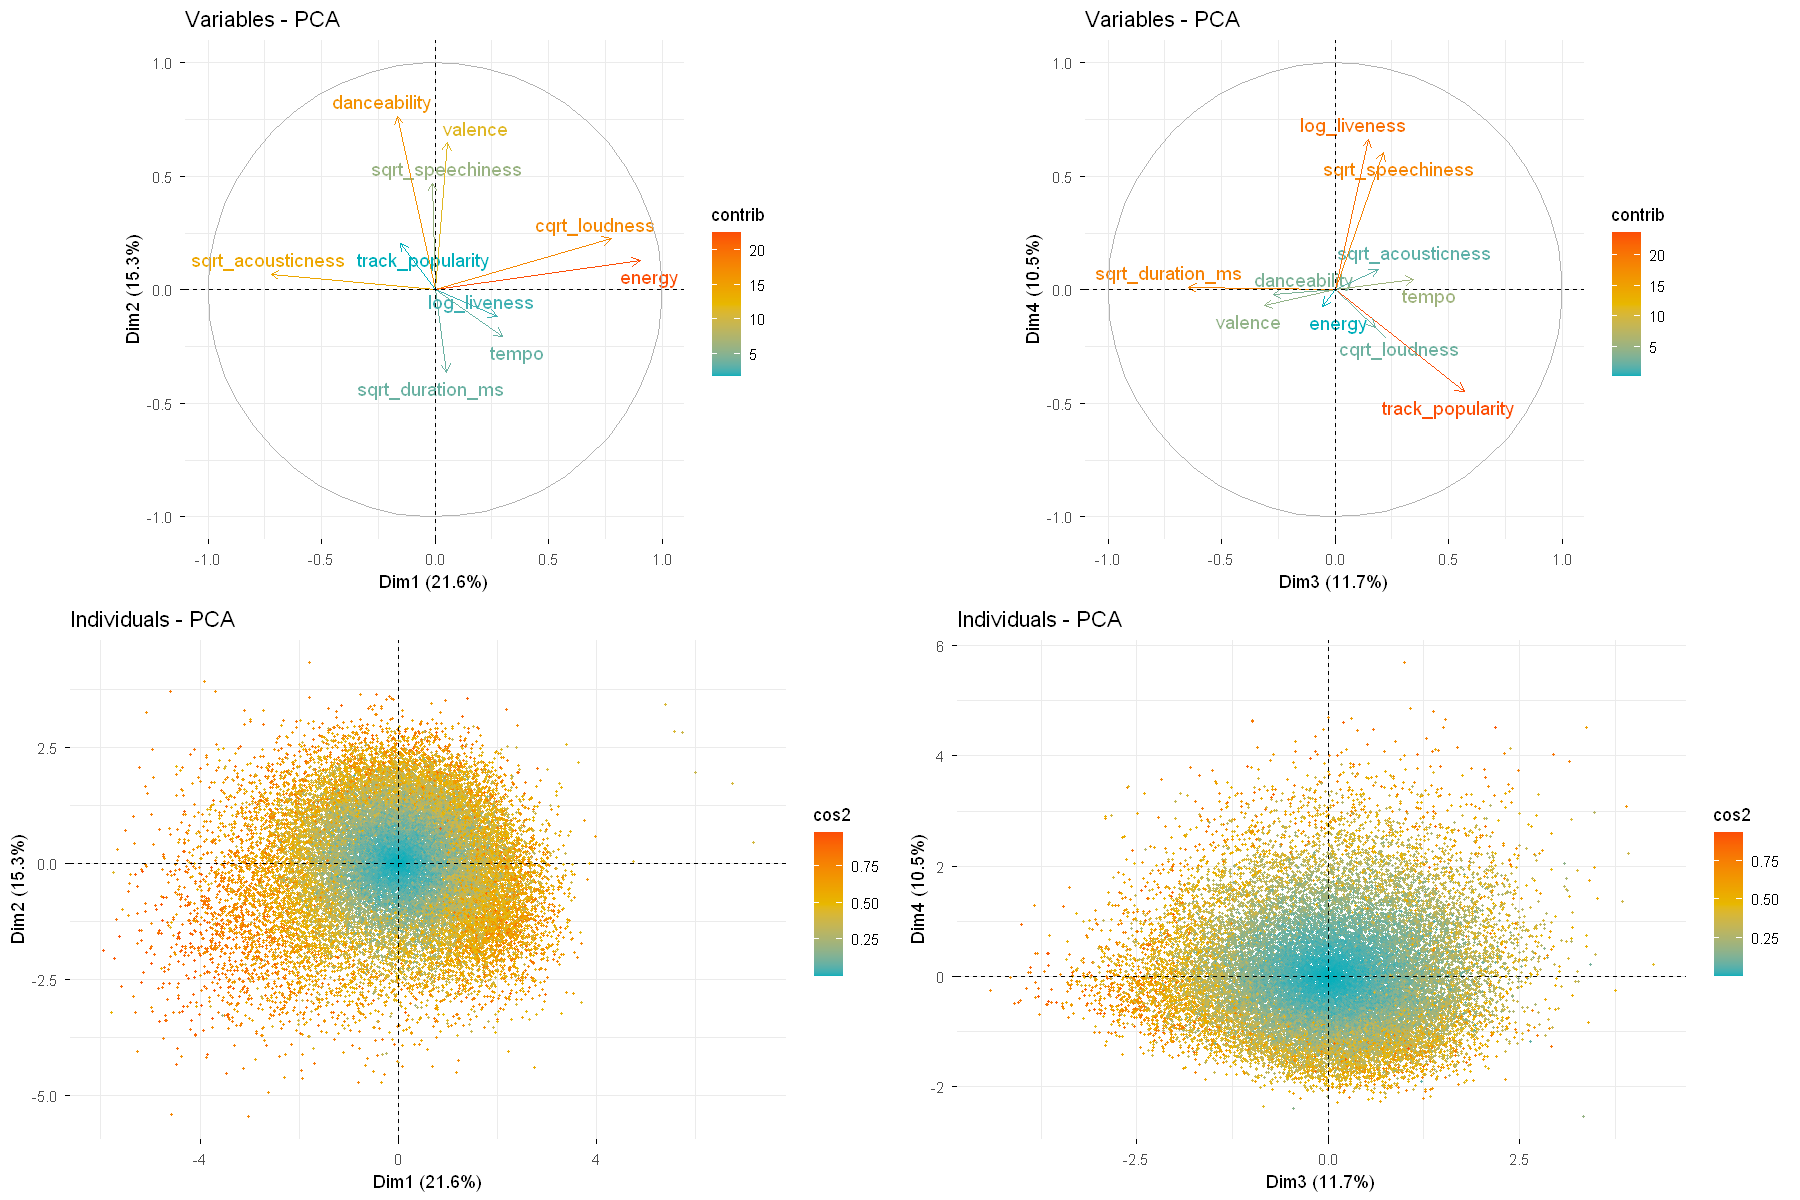

In [ ]:
#Visualiser les résultats de l'ACP
p1 <- fviz_pca_var(df.acp, col.var = "contrib",gradient.cols = c("#00AFBB", "#E7B800", "#FC4E07"),repel = TRUE)
p2 <- fviz_pca_var(df.acp, col.var = "contrib",gradient.cols = c("#00AFBB", "#E7B800", "#FC4E07"),axes= c(3,4),repel = TRUE)
p3 <- fviz_pca_ind(df.acp,col.ind = "cos2",label='none',gradient.cols = c("#00AFBB", "#E7B800", "#FC4E07"),pointsize = 0.5)
p4 <- fviz_pca_ind(df.acp,col.ind = "cos2",label='none',gradient.cols = c("#00AFBB", "#E7B800", "#FC4E07"),pointsize = 0.5,axes = c(3,4))
options(repr.plot.width = 15, repr.plot.height = 10)
grid.arrange(p1, p2, p3, p4, ncol = 2)

Warning message in geom_bar(stat = "identity", fill = barfill, color = barcolor, :
"Ignoring empty aesthetic: `width`."


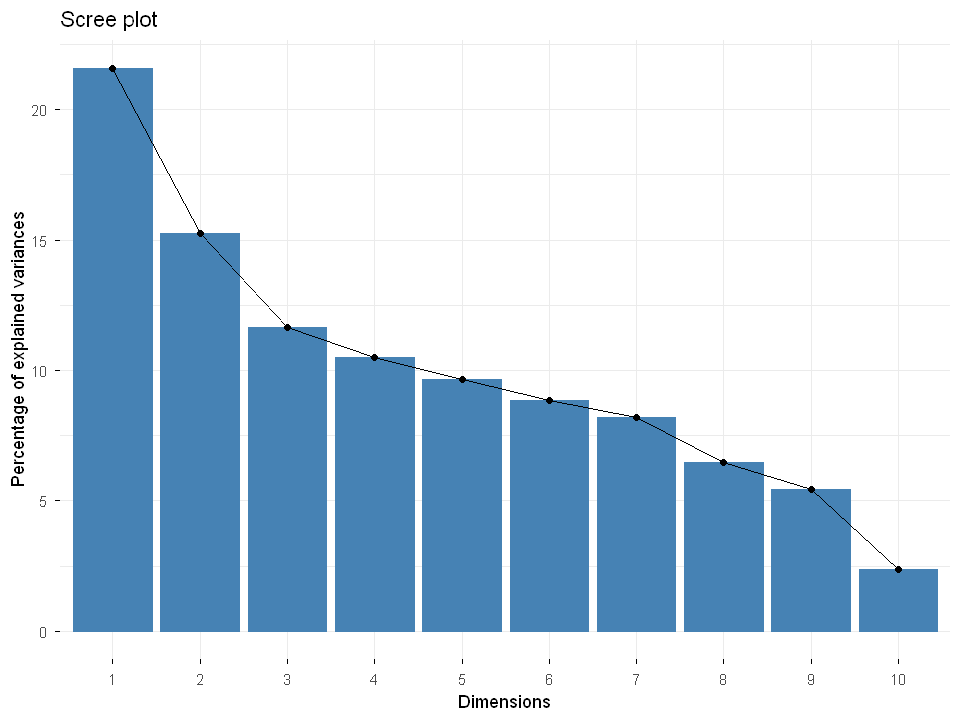

In [ ]:
# Variance expliquée par les composantes principales
options(repr.plot.width = 8, repr.plot.height = 6)
fviz_eig(df.acp)

## 2. LDA

In [63]:
#LDA
genre_num_df <- df %>% dplyr :: select(playlist_genre, where(is.numeric)) %>% na.omit()
genre_num_df$playlist_genre <- as.factor(genre_num_df$playlist_genre)
df.lda <- lda(playlist_genre ~ ., data = genre_num_df)
df.lda.pred <- predict(df.lda)
df.lda.acp <- PCA(genre_num_df,scale.unit = TRUE,quali.sup = 1)


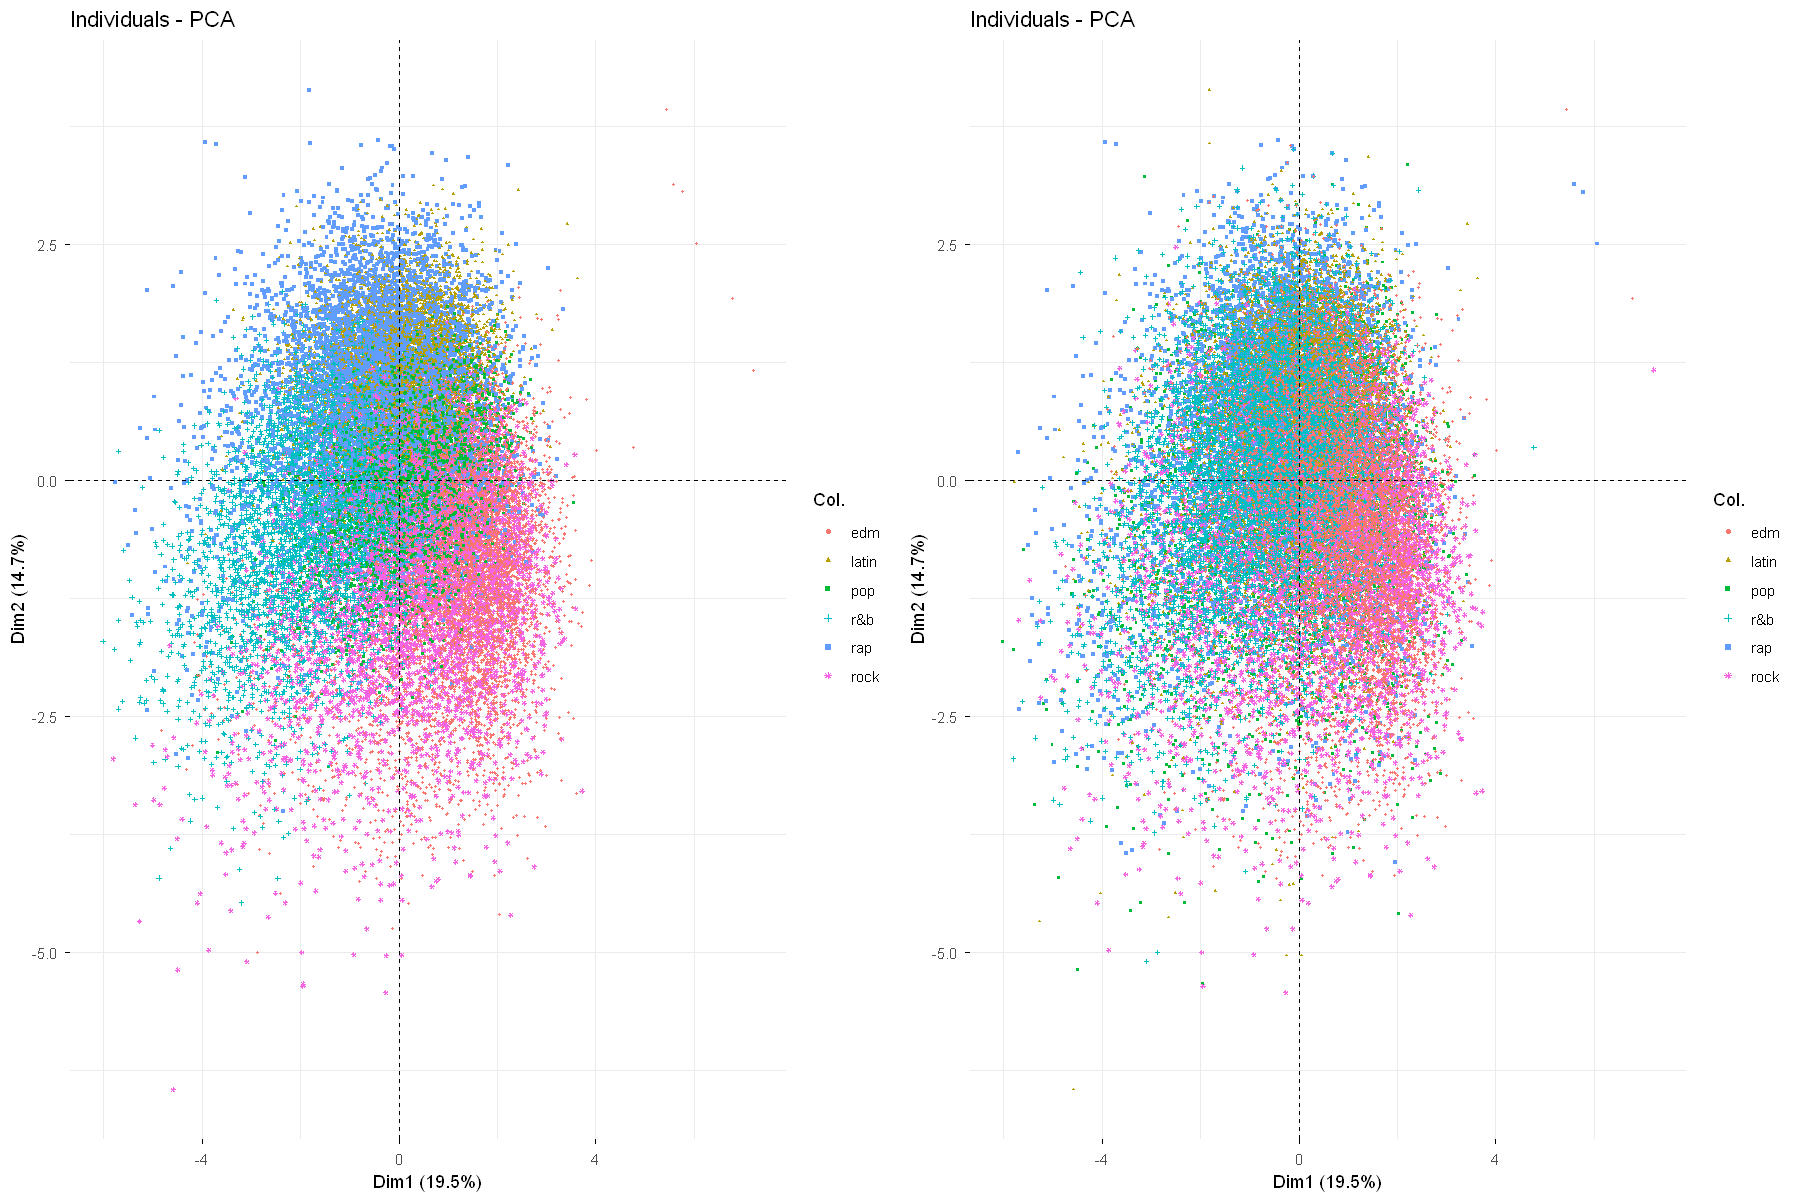

In [ ]:
#Comparer les classes prédites par LDA avec les genres réelles
p1 <- fviz_pca_ind(df.lda.acp, col.ind = df.lda.pred$class,label='none',pointsize = 0.5)
p2 <- fviz_pca_ind(df.lda.acp, col.ind = df$playlist_genre,label='none',pointsize = 0.5)
options(repr.plot.width = 15, repr.plot.height = 10)
grid.arrange(p1, p2, ncol = 2)

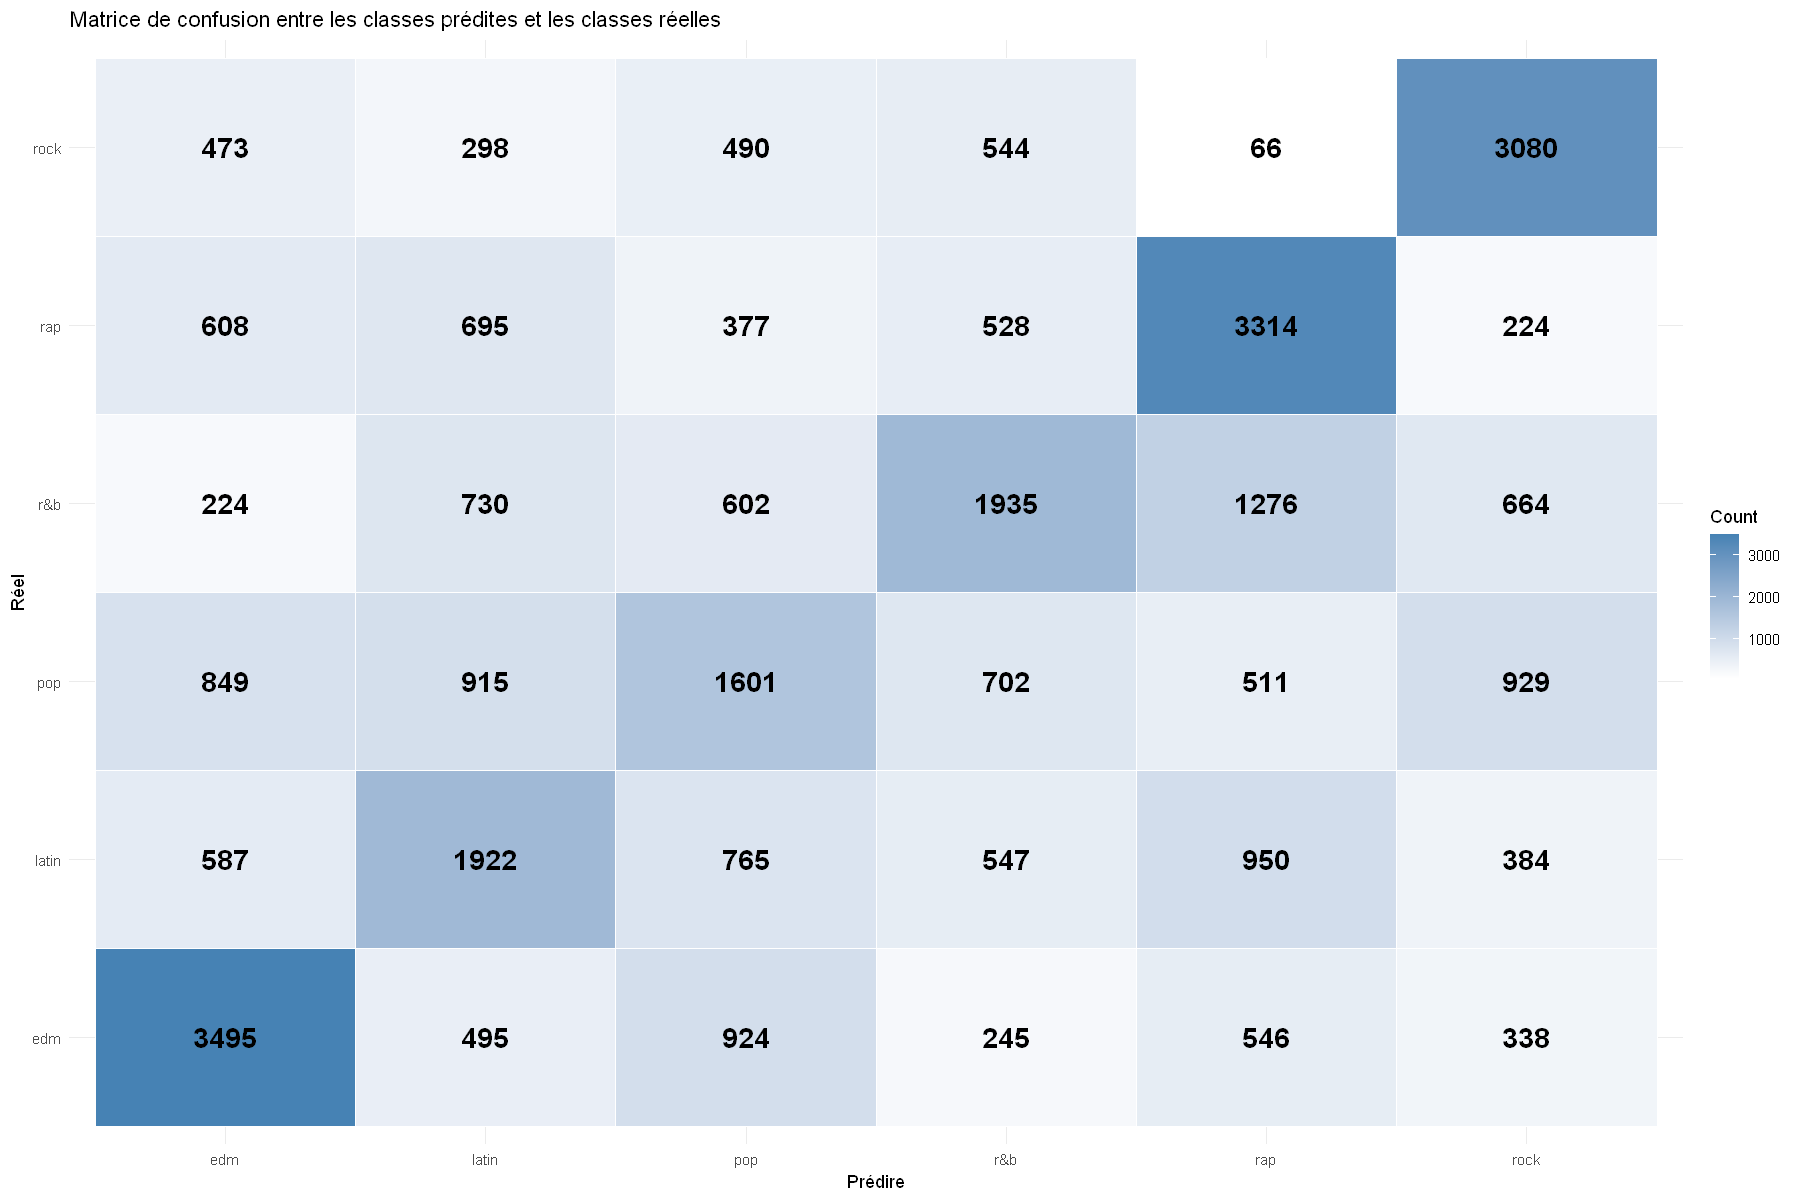

In [ ]:
# Confusion matrix
cm <- as.data.frame(table(Prédire = df.lda.pred$class, Réel = genre_num_df$playlist_genre))
ggplot(cm, aes(x = Prédire, y = Réel, fill = Freq)) +
  geom_tile(color = "white") +
  geom_text(aes(label = Freq), size = 6, fontface = "bold") +
  scale_fill_gradient(low = "white", high = "steelblue") +
  theme_minimal() +
  labs(title = "Matrice de confusion entre les classes prédites et les classes réelles", fill = "Count")

## 3. CA

In [ ]:
# CA entre les paires de variables catégorielles utiles pour l'analyse de la popularité
table.key_genre <- table(cat_df$key, cat_df$playlist_genre)
df.ca.key_genre <- CA(table.key_genre, graph = FALSE)
p1 <- fviz_ca_biplot(df.ca.key_genre, repel = TRUE)
p2 <- fviz_screeplot(df.ca.key_genre, addlabels = TRUE, ylim = c(0, 100))
table.key_subgenre <- table(cat_df$key, cat_df$playlist_subgenre)
df.ca.key_subgenre <- CA(table.key_subgenre, graph = FALSE)
p3 <- fviz_ca_biplot(df.ca.key_subgenre, repel = TRUE)
p4 <- fviz_screeplot(df.ca.key_subgenre, addlabels = TRUE, ylim = c(0, 100),repel = TRUE)
table.year_genre <- table(cat_df$year, cat_df$playlist_genre)
df.ca.year_genre <- CA(table.year_genre, graph = FALSE)
p5 <- fviz_ca_biplot(df.ca.year_genre, repel = TRUE)
p6 <- fviz_screeplot(df.ca.year_genre, addlabels = TRUE, ylim = c(0, 100),repel = TRUE)
table.year_subgenre <- table(cat_df$year, cat_df$playlist_subgenre)
df.ca.year_subgenre <- CA(table.year_subgenre, graph = FALSE)
p7 <- fviz_ca_biplot(df.ca.year_subgenre, repel = TRUE)
p8 <- fviz_screeplot(df.ca.year_subgenre, addlabels = TRUE)
table.quarter_genre <- table(cat_df$quarter, cat_df$playlist_genre)
df.ca.quarter_genre <- CA(table.quarter_genre, graph = FALSE)
p9 <- fviz_ca_biplot(df.ca.quarter_genre, repel = TRUE)
p10 <-fviz_screeplot(df.ca.quarter_genre, addlabels = TRUE, ylim = c(0, 100),repel = TRUE)
table.quarter_subgenre <- table(cat_df$quarter, cat_df$playlist_subgenre)
df.ca.quarter_subgenre <- CA(table.quarter_subgenre, graph = FALSE)
p11 <- fviz_ca_biplot(df.ca.quarter_subgenre, repel = TRUE)
p12 <- fviz_screeplot(df.ca.quarter_subgenre, addlabels = TRUE, ylim = c(0, 100),repel = TRUE)
table.quarter_popularity <- table(cat_df$quarter, cat_df$factor_popularity)
df.ca.quarter_popularity <- CA(table.quarter_popularity, graph = FALSE)
p13 <- fviz_ca_biplot(df.ca.quarter_popularity, repel = TRUE)
p14 <- fviz_screeplot(df.ca.quarter_popularity, addlabels = TRUE, ylim = c(0, 100),repel = TRUE)
table.genre_popularity <- table(cat_df$playlist_genre, cat_df$factor_popularity)
df.ca.genre_popularity <- CA(table.genre_popularity, graph = FALSE)
p15 <- fviz_ca_biplot(df.ca.genre_popularity, repel = TRUE)
p16 <- fviz_screeplot(df.ca.genre_popularity, addlabels = TRUE, ylim = c(0, 100),repel = TRUE)



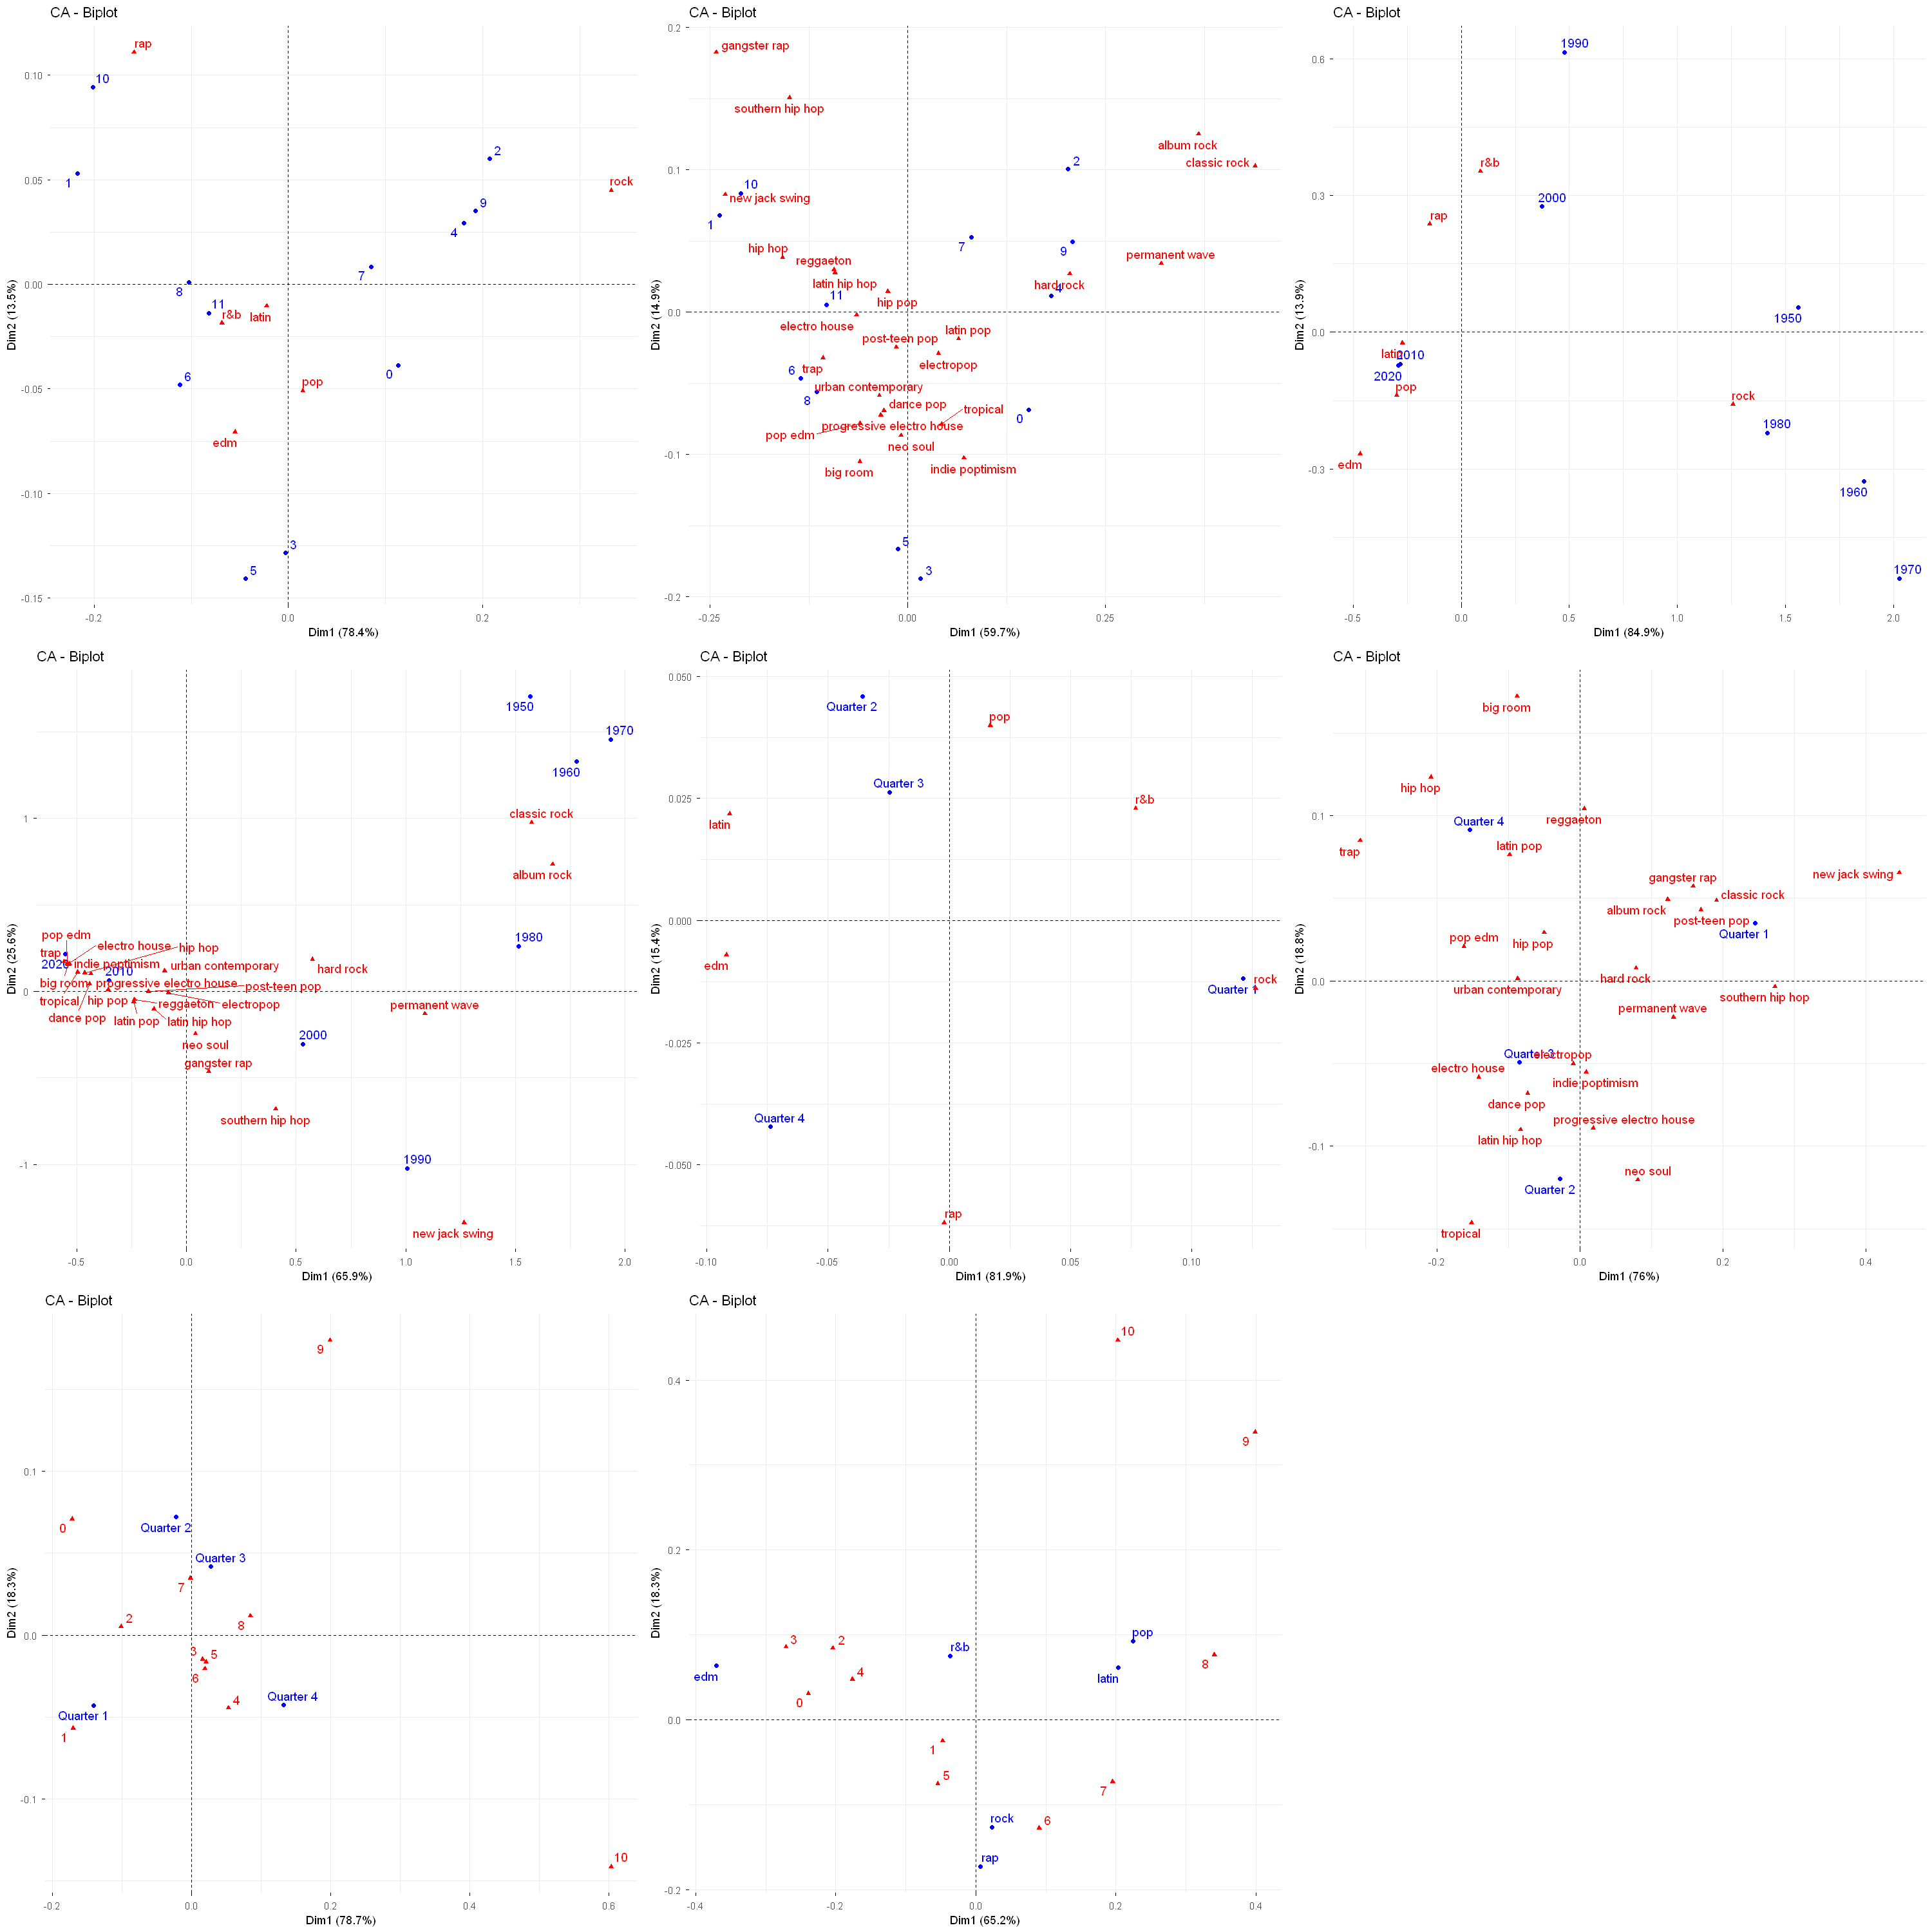

In [ ]:
# Visualiser la corrélation entre les variables catégorielles 
options(repr.plot.width = 25, repr.plot.height = 25)
grid.arrange(p1, p3, p5, p7, p9, p11, p13, p15, ncol = 3)

Warning message in geom_bar(stat = "identity", fill = barfill, color = barcolor, :
"Ignoring empty aesthetic: `width`."
Warning message in geom_bar(stat = "identity", fill = barfill, color = barcolor, :
"Ignoring empty aesthetic: `width`."
Warning message in geom_bar(stat = "identity", fill = barfill, color = barcolor, :
"Ignoring empty aesthetic: `width`."
Warning message in geom_bar(stat = "identity", fill = barfill, color = barcolor, :
"Ignoring empty aesthetic: `width`."
Warning message in geom_bar(stat = "identity", fill = barfill, color = barcolor, :
"Ignoring empty aesthetic: `width`."
Warning message in geom_bar(stat = "identity", fill = barfill, color = barcolor, :
"Ignoring empty aesthetic: `width`."
Warning message in geom_bar(stat = "identity", fill = barfill, color = barcolor, :
"Ignoring empty aesthetic: `width`."
Warning message in geom_bar(stat = "identity", fill = barfill, color = barcolor, :
"Ignoring empty aesthetic: `width`."


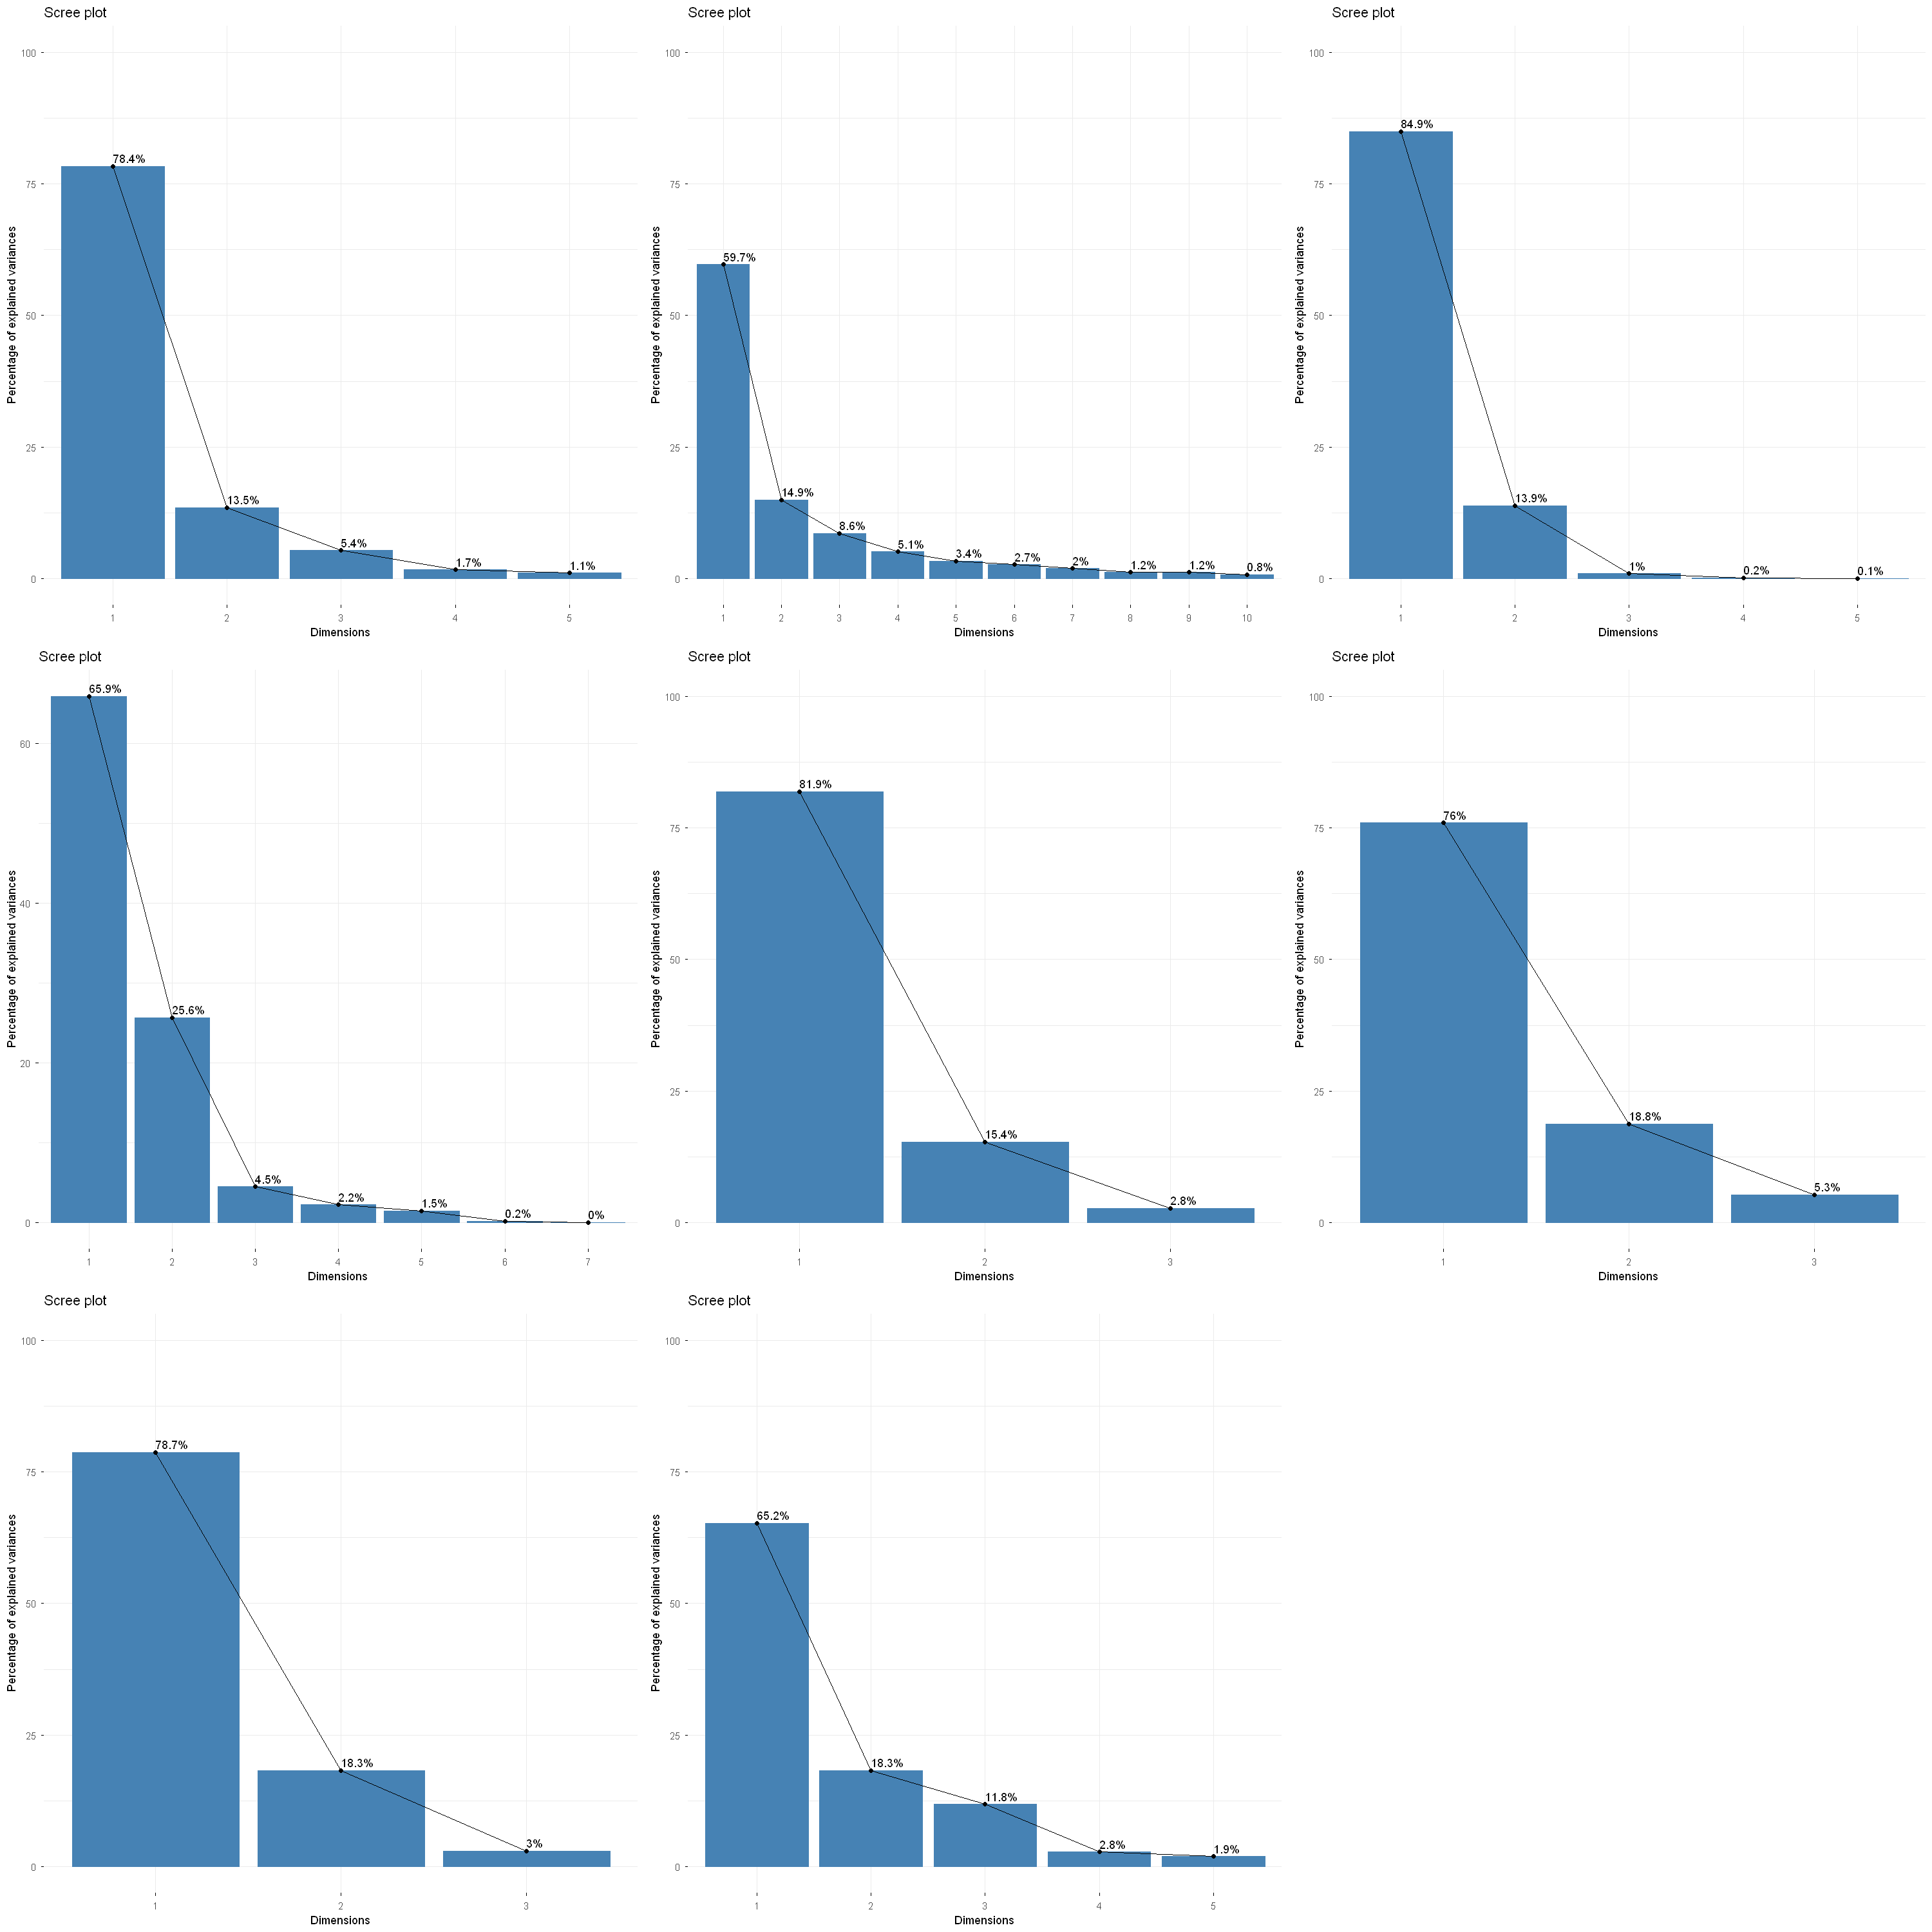

In [ ]:
# Visualiser les screeplots pour chaque CA
grid.arrange(p2, p4, p6, p8, p10, p12, p14, p16, ncol = 3)

Warning message in geom_bar(stat = "identity", fill = barfill, color = barcolor, :
"Ignoring empty aesthetic: `width`."


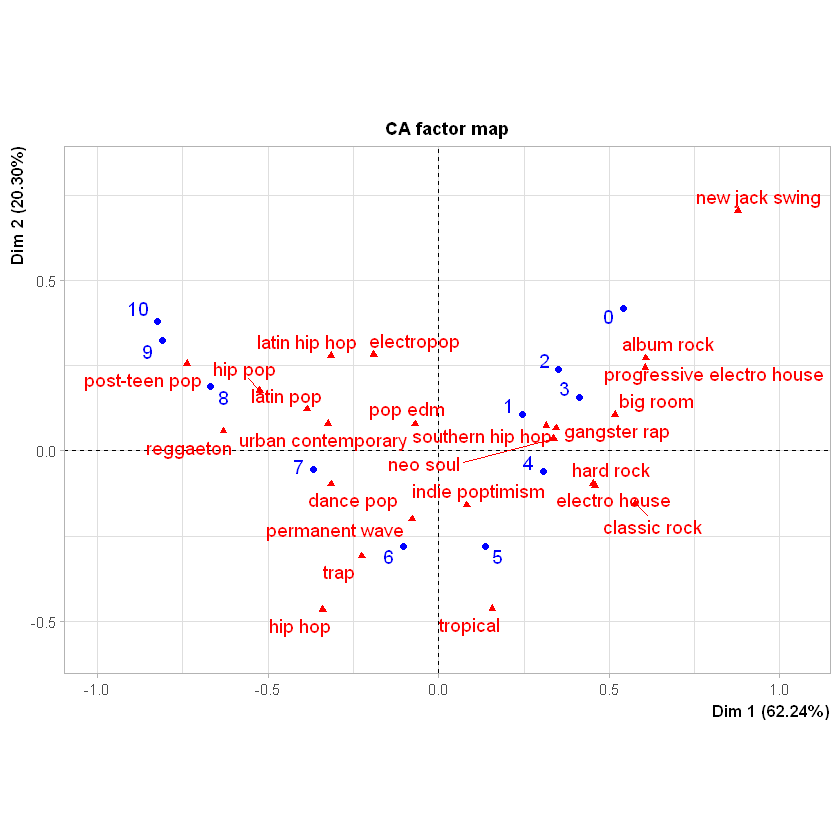

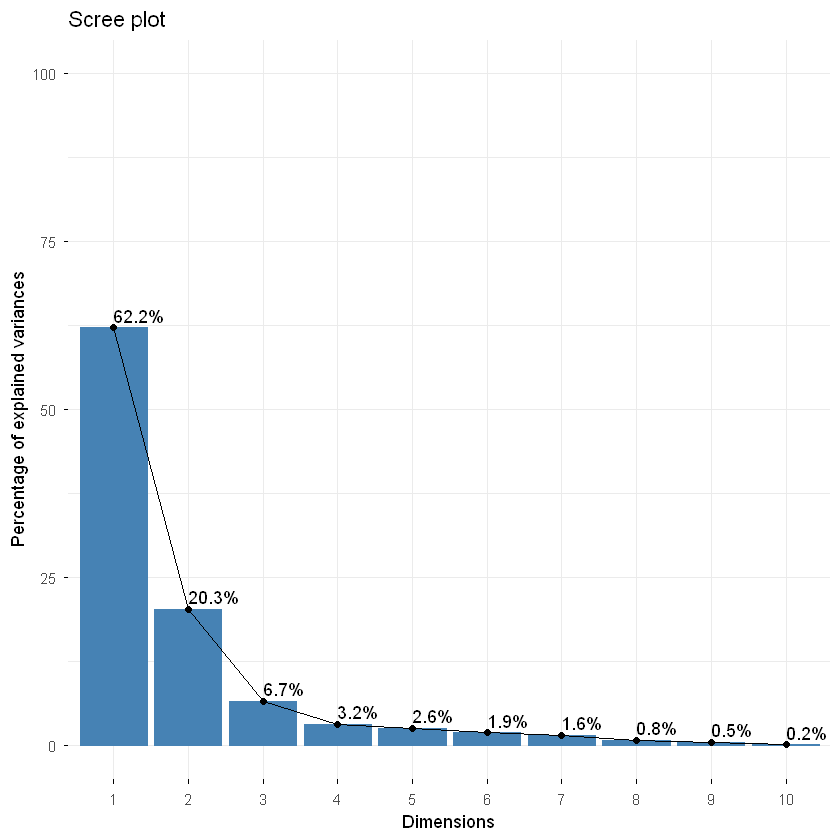

In [ ]:

table.quarter_genre <- table(cat_df[cat_df$year == 2020 | cat_df$year == 2010,]$factor_popularity, cat_df[cat_df$year == 2020 | cat_df$year == 2010,]$playlist_genre)
df.ca.quarter_genre <- CA(table.quarter_genre, graph = TRUE)
fviz_screeplot(df.ca.quarter_genre, addlabels = TRUE, ylim = c(0, 100),repel = TRUE)

Warning message in CA(table.quarter_subgenre, graph = TRUE):
"The rows 10 sum at 0. They were suppressed from the analysis"
Warning message in CA(table.quarter_subgenre, graph = TRUE):
"The columns pop edm, trap sum at 0. They were suppressed from the analysis"
Warning message in geom_bar(stat = "identity", fill = barfill, color = barcolor, :
"Ignoring empty aesthetic: `width`."


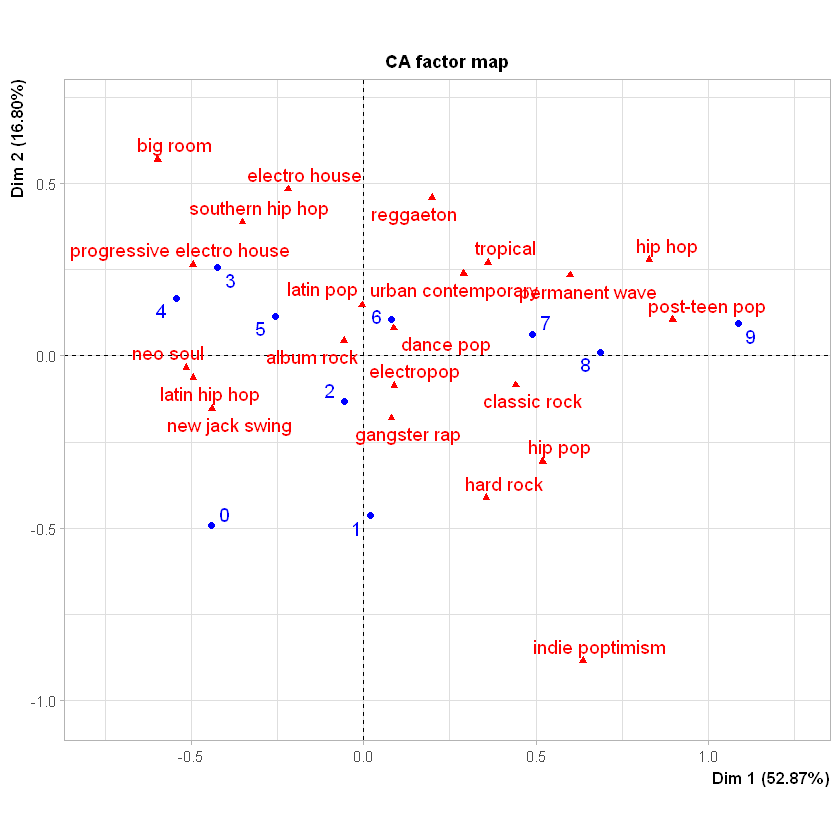

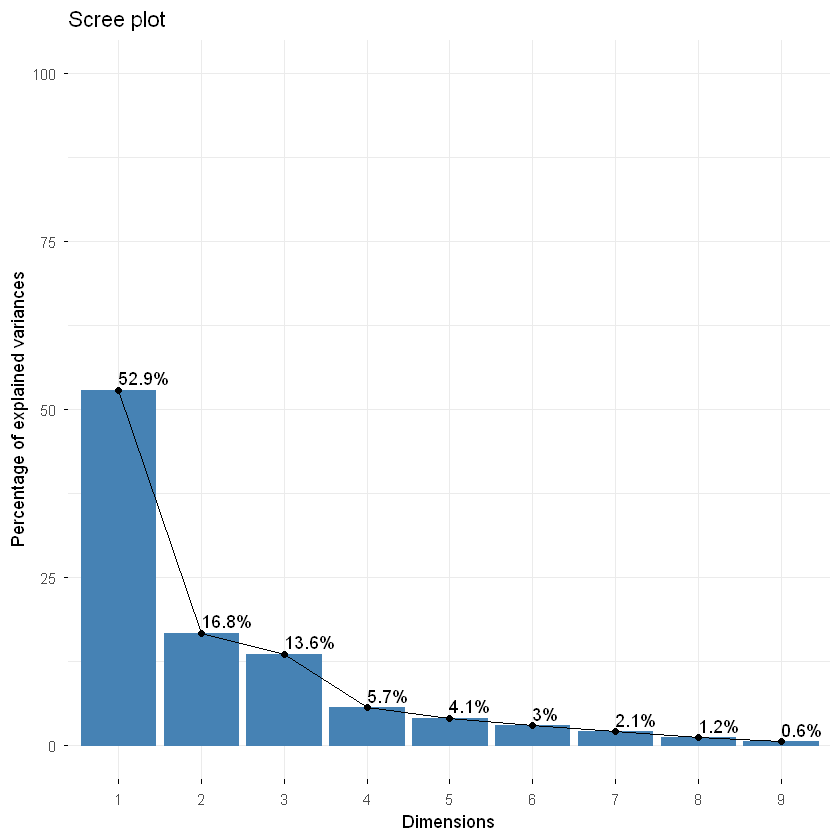

In [ ]:
table.quarter_genre <- table(cat_df[cat_df$year == 1990 | cat_df$year == 2000,]$factor_popularity, cat_df[cat_df$year == 1990 | cat_df$year == 2000,]$playlist_genre)
df.ca.quarter_genre <- CA(table.quarter_genre, graph = TRUE)
fviz_screeplot(df.ca.quarter_genre, addlabels = TRUE, ylim = c(0, 100),repel = TRUE)

Warning message in CA(table.quarter_subgenre, graph = TRUE):
"The rows 10 sum at 0. They were suppressed from the analysis"
Warning message in CA(table.quarter_subgenre, graph = TRUE):
"The columns big room, dance pop, electro house, gangster rap, hip hop, hip pop, indie poptimism, pop edm, reggaeton, trap, tropical sum at 0. They were suppressed from the analysis"
Warning message in geom_bar(stat = "identity", fill = barfill, color = barcolor, :
"Ignoring empty aesthetic: `width`."


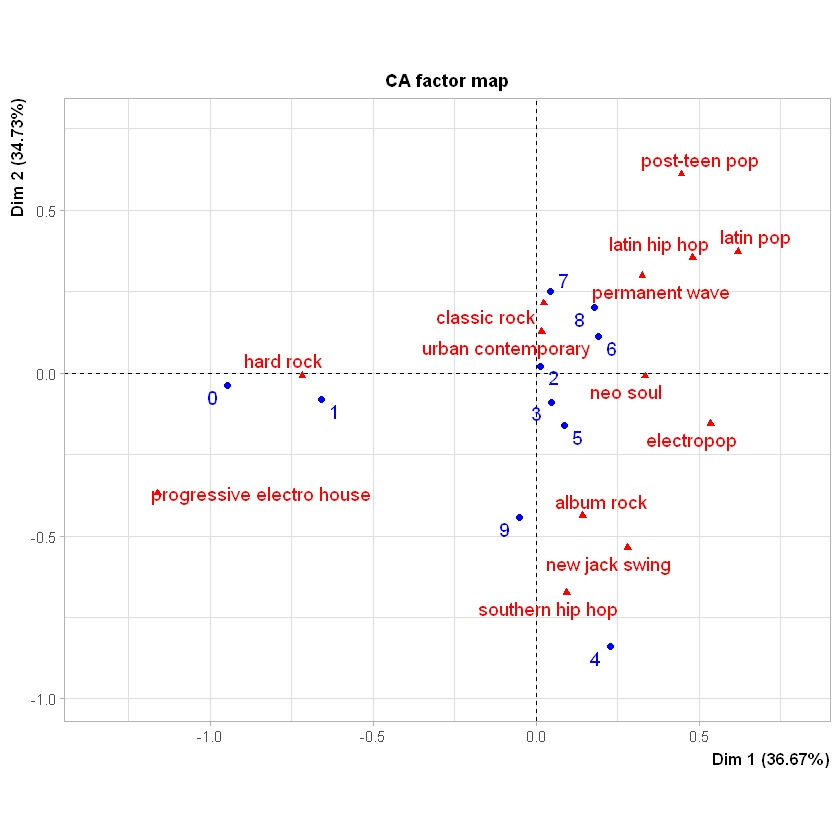

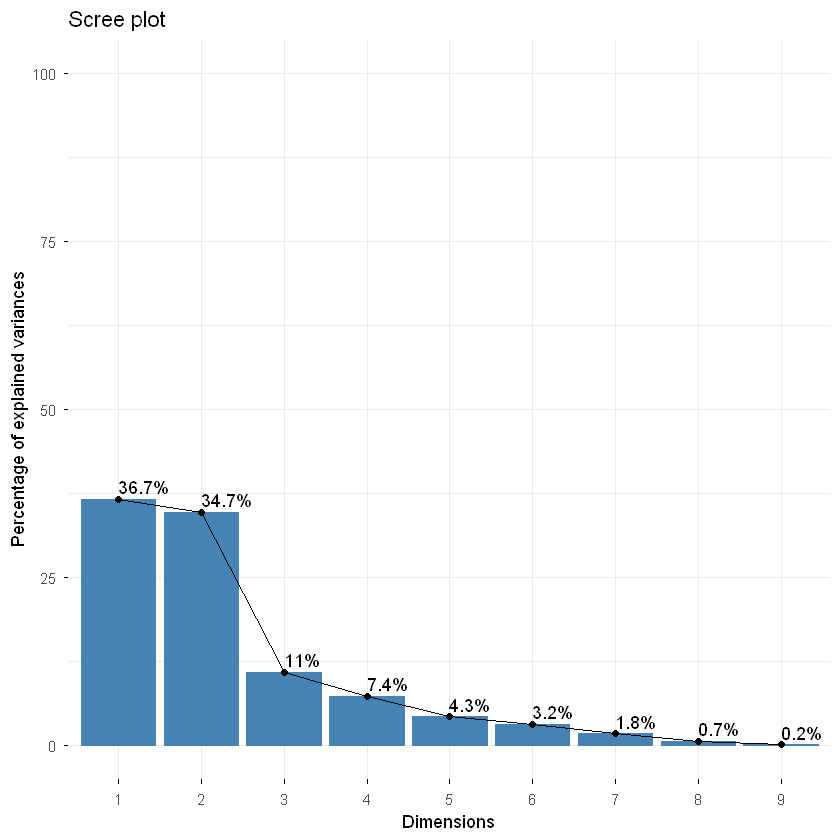

In [ ]:
table.quarter_genre <- table(cat_df[cat_df$year == 1980 | cat_df$year == 1970,]$factor_popularity, cat_df[cat_df$year == 1980 | cat_df$year == 1970,]$playlist_genre)
df.ca.quarter_genre <- CA(table.quarter_genre, graph = TRUE)
fviz_screeplot(df.ca.quarter_genre, addlabels = TRUE, ylim = c(0, 100),repel = TRUE)

In [ ]:
table.quarter_genre <- table(cat_df[cat_df$year == 1960 | cat_df$year == 1950,]$factor_popularity, cat_df[cat_df$year == 1950 | cat_df$year == 1960,]$playlist_genre)
df.ca.quarter_genre <- CA(table.quarter_genre, graph = TRUE)
fviz_screeplot(df.ca.quarter_genre, addlabels = TRUE, ylim = c(0, 100),repel = TRUE)

In [ ]:
# Table de contingence
options(repr.plot.width = 8, repr.plot.height = 6)

tab_genre_pop <- table(df$playlist_genre, df$factor_popularity)

# AFC
afc1 <- CA(tab_genre_pop, graph = FALSE)

# Visualisation
fviz_ca_biplot(afc1, repel = TRUE, ggtheme = theme_minimal()) +
  labs(title = "AFC — Genre × Popularité")

In [ ]:
tab_genre_dec <- table(df$playlist_genre, df$year)

afc2 <- CA(tab_genre_dec, graph = FALSE)

fviz_ca_biplot(afc2, repel = TRUE, ggtheme = theme_minimal()) +
  labs(title = "AFC — Genre × Décennie")

## 4. MCA

### MCA avec variables temporelles

In [78]:
cat_df.sub <- subset(cat_df, select = -c(playlist_subgenre, bool_instrumentalness,month))
head(cat_df.sub)

In [79]:
df.mca <- MCA(cat_df.sub, graph = FALSE)
print(df.mca)

**Results of the Multiple Correspondence Analysis (MCA)**
The analysis was performed on 32833 individuals, described by 6 variables
*The results are available in the following objects:

   name              description                       
1  "$eig"            "eigenvalues"                     
2  "$var"            "results for the variables"       
3  "$var$coord"      "coord. of the categories"        
4  "$var$cos2"       "cos2 for the categories"         
5  "$var$contrib"    "contributions of the categories" 
6  "$var$v.test"     "v-test for the categories"       
7  "$var$eta2"       "coord. of variables"             
8  "$ind"            "results for the individuals"     
9  "$ind$coord"      "coord. for the individuals"      
10 "$ind$cos2"       "cos2 for the individuals"        
11 "$ind$contrib"    "contributions of the individuals"
12 "$call"           "intermediate results"            
13 "$call$marge.col" "weights of columns"              
14 "$call$marge.li"  "weights 

In [80]:
head(df.mca$eig)

,eigenvalue,percentage of variance,cumulative percentage of variance
dim 1,0.3131804,4.944953,4.944953
dim 2,0.2335330,3.687362,8.632316
dim 3,0.2130743,3.364332,11.996647
dim 4,0.2031442,3.207540,15.204188
dim 5,0.2001188,3.159770,18.363958
dim 6,0.1940449,3.063867,21.427825


Warning message in geom_bar(stat = "identity", fill = barfill, color = barcolor, :
"Ignoring empty aesthetic: `width`."


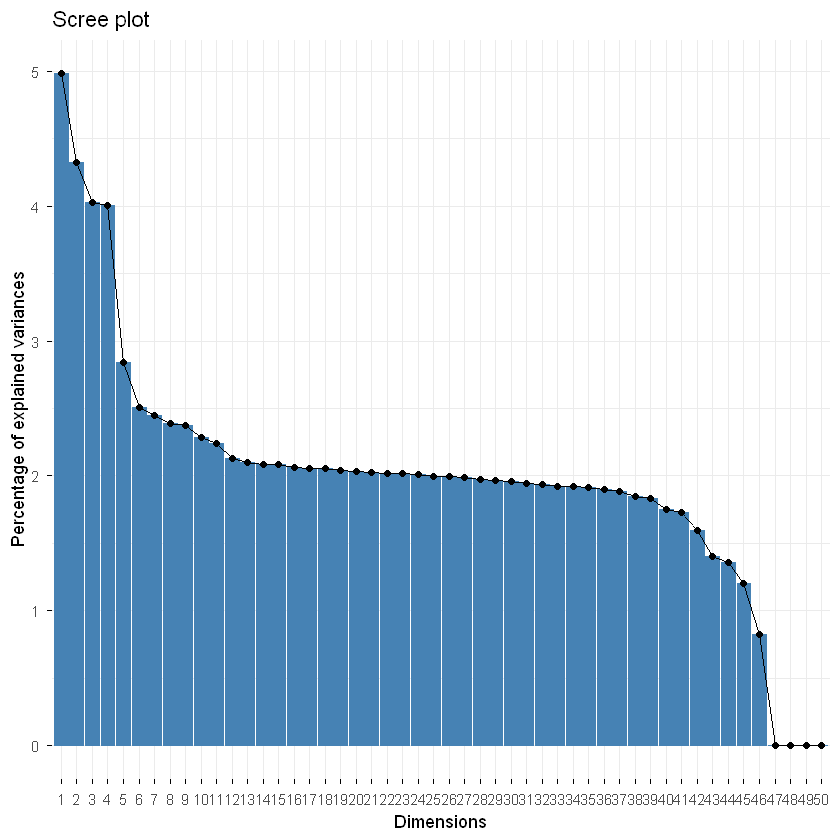

In [ ]:
fviz_screeplot(df.mca, addlabels = FALSE,ncp = 54)

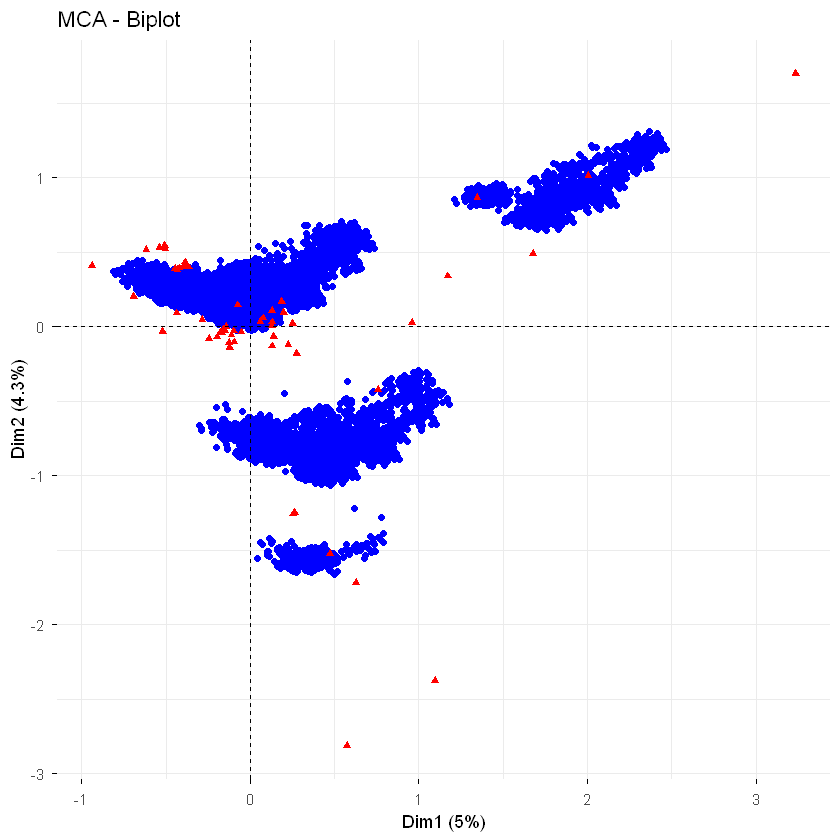

In [ ]:
fviz_mca_biplot(df.mca, label = "var", repel = TRUE, ggtheme = theme_minimal())

In [ ]:
fviz_contrib(df.mca, choice = "var", axes = 1, top = 10)
fviz_contrib(df.mca, choice = "var", axes = 2, top = 10)

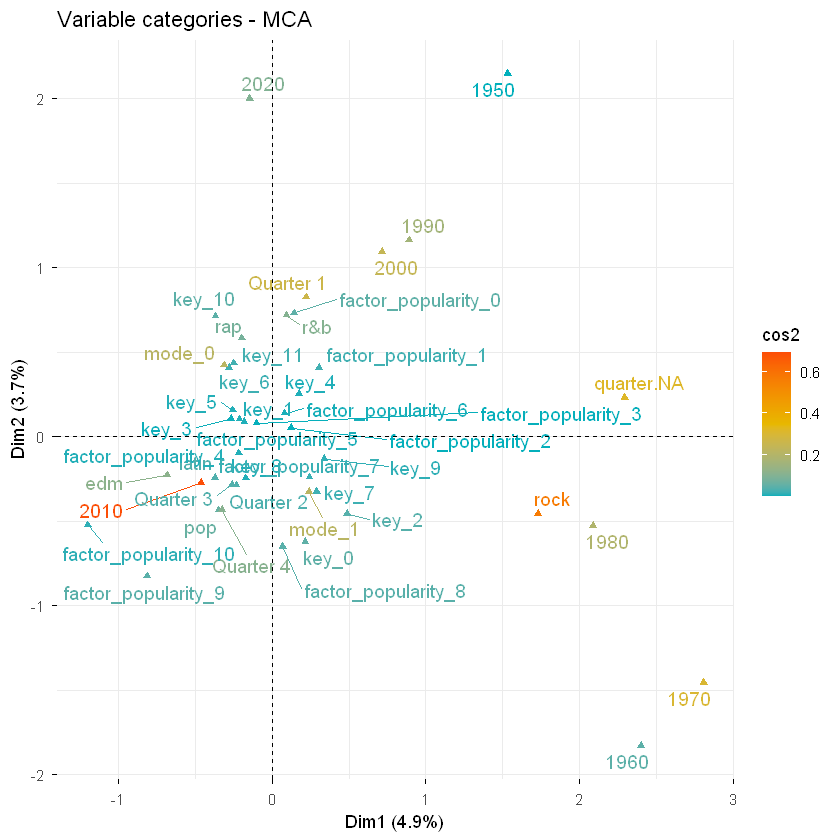

In [ ]:
fviz_mca_var(df.mca, col.var = "cos2", gradient.cols = c("#00AFBB", "#E7B800", "#FC4E07"), repel = TRUE)

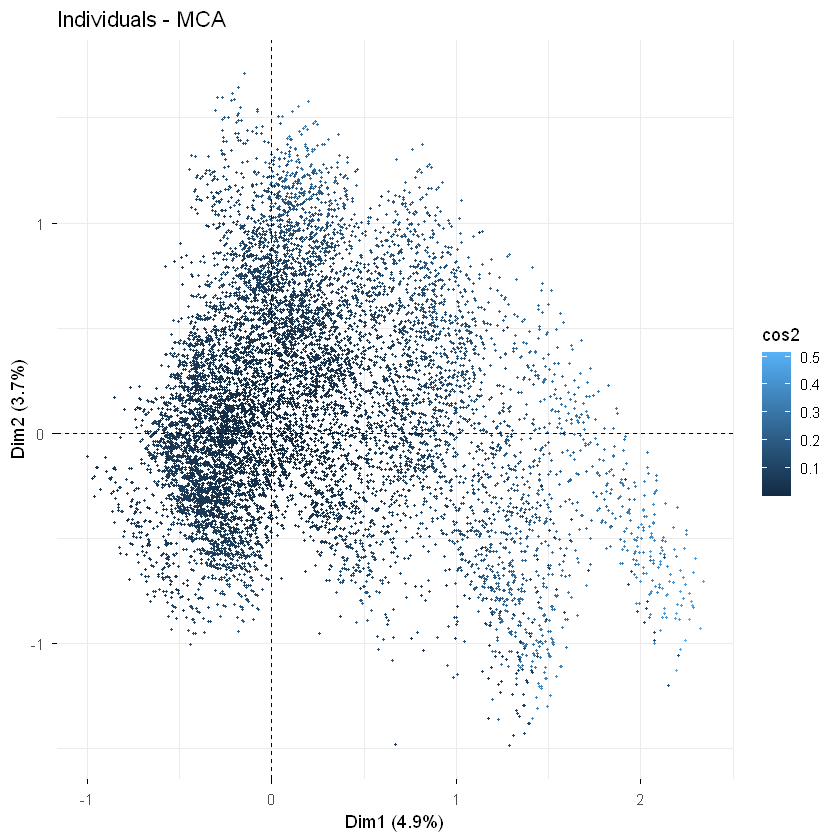

In [ ]:
fviz_mca_ind(df.mca, col.ind = "cos2", label = "none", pointsize = 0.5, ggtheme = theme_minimal())

In [ ]:
fviz_mca_ind(df.mca, col.ind = cat_df.sub$playlist_genre,
             label = "none", pointsize = 0.5,
             addEllipses = TRUE,
             ggtheme = theme_minimal())

In [ ]:
table(df$playlist_genre, df$year) %>% 
  prop.table(margin = 1) %>% 
  round(2)

In [ ]:
fviz_mca_ind(df.mca, col.ind = cat_df.sub$factor_popularity,
             label = "none", pointsize = 0.5,
             addEllipses = TRUE,
             ggtheme = theme_minimal())

### MCA sans les variables temporelles

In [ ]:
cat_df.sans_year <- cat_df.sub %>% dplyr::select(-year, -quarter)
df.mca2 <- MCA(cat_df.sans_year, graph = FALSE)
fviz_mca_biplot(df.mca2, label = "var", repel = TRUE)

In [ ]:
fviz_contrib(df.mca2, choice = "var", axes = 1, top = 10)
fviz_contrib(df.mca2, choice = "var", axes = 2, top = 10)

In [ ]:
fviz_mca_var(df.mca2, col.var = "cos2",
             gradient.cols = c("#00AFBB", "#E7B800", "#FC4E07"),
             repel = TRUE, ggtheme = theme_minimal())

In [ ]:
fviz_mca_ind(df.mca2, col.ind = cat_df.sans_year$playlist_genre,
             label = "none", pointsize = 0.5,
             addEllipses = TRUE,
             ggtheme = theme_minimal())

In [ ]:
fviz_mca_ind(df.mca2, col.ind = cat_df.sans_year$factor_popularity,
             label = "none", pointsize = 0.5,
             addEllipses = TRUE,
             ggtheme = theme_minimal())

# III. Clustering

## 1. K-means

df_scaled : 28330 x 10  |  moyenne ≈ 6.77e-17  |  std ≈ 1.0000


Warning message:
"Quick-TRANSfer stage steps exceeded maximum (= 1416500)"
Warning message:
"did not converge in 10 iterations"
Warning message:
"did not converge in 10 iterations"
Warning message:
"did not converge in 10 iterations"
Warning message:
"did not converge in 10 iterations"
Warning message:
"did not converge in 10 iterations"
Warning message:
"did not converge in 10 iterations"
Warning message:
"did not converge in 10 iterations"
Warning message:
"did not converge in 10 iterations"
Warning message:
"did not converge in 10 iterations"
Warning message:
"did not converge in 10 iterations"
Warning message:
"Quick-TRANSfer stage steps exceeded maximum (= 1416500)"
Warning message:
"did not converge in 10 iterations"
Warning message:
"did not converge in 10 iterations"
Warning message:
"did not converge in 10 iterations"
Warning message:
"did not converge in 10 iterations"
Warning message in element_line(alpha = 0.4):
"`...` must be empty.
✖ Problematic argument:
• alpha = 0.4"
W

k optimal (silhouette) : 2 


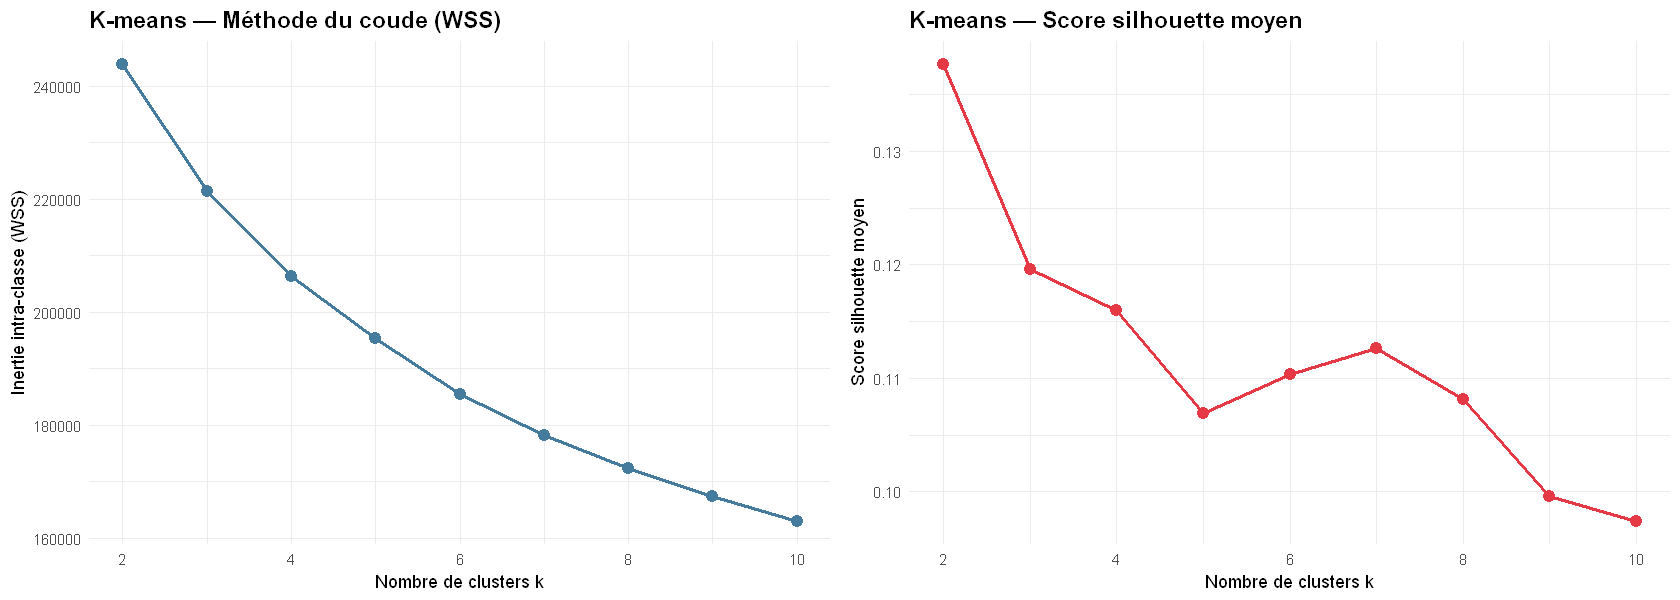

In [84]:
# Scale the data
df_scaled <- scale(num_df)

# Print summary
cat(sprintf("df_scaled : %s  |  moyenne ≈ %.2e  |  std ≈ %.4f\n",
            paste(dim(df_scaled), collapse = " x "),
            mean(df_scaled),
            sd(df_scaled)))
# ── Choix de k : méthode du coude (WSS) + silhouette ─────────────────────────
k_range <- 2:10
inertias <- c()
sil_scores <- c()

for (k in k_range) {
  km_tmp <- kmeans(df_scaled, centers = k, nstart = 10)
  inertias <- c(inertias, km_tmp$tot.withinss)
  sil <- silhouette(km_tmp$cluster, dist(df_scaled))
  sil_scores <- c(sil_scores, mean(sil[, 3]))
}

df_plot <- data.frame(k = k_range, inertia = inertias, silhouette = sil_scores)

# Coude WSS
p1 <- ggplot(df_plot, aes(x = k, y = inertia)) +
  geom_line(color = "#457B9D", linewidth = 1) +
  geom_point(color = "#457B9D", size = 3) +
  labs(title = "K-means — Méthode du coude (WSS)",
       x = "Nombre de clusters k",
       y = "Inertie intra-classe (WSS)") +
  theme_minimal() +
  theme(plot.title = element_text(face = "bold", size = 14),
        panel.grid = element_line(alpha = 0.4))

# Silhouette
p2 <- ggplot(df_plot, aes(x = k, y = silhouette)) +
  geom_line(color = "#E63946", linewidth = 1) +
  geom_point(color = "#E63946", size = 3) +
  labs(title = "K-means — Score silhouette moyen",
       x = "Nombre de clusters k",
       y = "Score silhouette moyen") +
  theme_minimal() +
  theme(plot.title = element_text(face = "bold", size = 14),
        panel.grid = element_line(alpha = 0.4))

options(repr.plot.width = 14, repr.plot.height = 5)
grid.arrange(p1, p2, ncol = 2)

# k optimal
k_optimal <- k_range[which.max(sil_scores)]
cat("k optimal (silhouette) :", k_optimal, "\n")

In [87]:
# ── Ajustement K-means ────────────────────────────────────────────────────────
# nstart=25 : 25 initialisations aléatoires, la meilleure est retenue
# iter.max=300 : nombre maximal d'itérations

k_optimal <- 7  # à ajuster d'après les graphiques ci-dessus

km <- kmeans(df_scaled, centers = k_optimal, nstart = 25, iter.max = 300)
labels_km <- km$cluster

cat(sprintf("Inertie intra-classe : %.2f\n", km$tot.withinss))
cat("Taille des clusters  :", table(labels_km), "\n")

Inertie intra-classe : 178231.12
Taille des clusters  : 2532 4189 6005 2374 3547 5574 4109 


Score silhouette moyen : 0.1126


Warning message in element_line(alpha = 0.4):
"`...` must be empty.
✖ Problematic argument:
• alpha = 0.4"


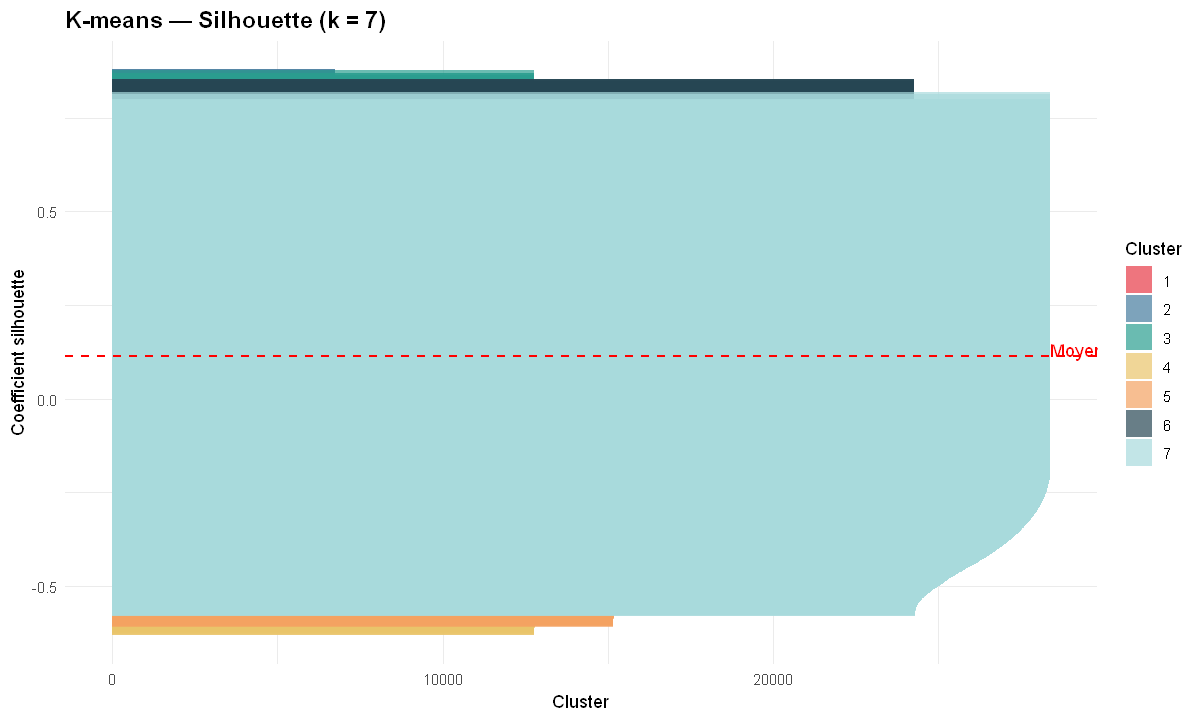

In [91]:
# ── Silhouette K-means ────────────────────────────────────────────────────────
sil_obj    <- silhouette(labels_km, dist(df_scaled))
sil_vals_km <- sil_obj[, 3]
sil_avg_km  <- mean(sil_vals_km)
cat(sprintf("Score silhouette moyen : %.4f\n", sil_avg_km))

# Build dataframe for ggplot
PALETTE <- c("#E63946", "#457B9D", "#2A9D8F", "#E9C46A", "#F4A261", "#264653", "#A8DADC")

df_sil <- data.frame(
  cluster = as.factor(labels_km),
  sil_val = sil_vals_km
)

# Sort within each cluster
df_sil <- df_sil[order(df_sil$cluster, df_sil$sil_val), ]
df_sil$y <- seq_len(nrow(df_sil))

# Add gaps between clusters
gap <- 10
df_sil$y_gap <- df_sil$y + as.integer(df_sil$cluster) * gap

# Plot
options(repr.plot.width = 10, repr.plot.height = 6)

ggplot(df_sil, aes(x = sil_val, y = y_gap, fill = cluster)) +
  geom_col(width = 1, alpha = 0.7) +
  geom_vline(xintercept = sil_avg_km, color = "red", linetype = "dashed",
             linewidth = 0.8) +
  annotate("text", x = sil_avg_km + 0.02, y = max(df_sil$y_gap),
           label = sprintf("Moyenne = %.3f", sil_avg_km), color = "red", hjust = 0) +
  scale_fill_manual(values = PALETTE, name = "Cluster") +
  labs(title = sprintf("K-means — Silhouette (k = %d)", k_optimal),
       x = "Coefficient silhouette",
       y = "Cluster") +
  theme_minimal() +
  theme(plot.title  = element_text(face = "bold", size = 14),
        panel.grid  = element_line(alpha = 0.4))+
  coord_flip()

Warning message in element_line(alpha = 0.3):
"`...` must be empty.
✖ Problematic argument:
• alpha = 0.3"


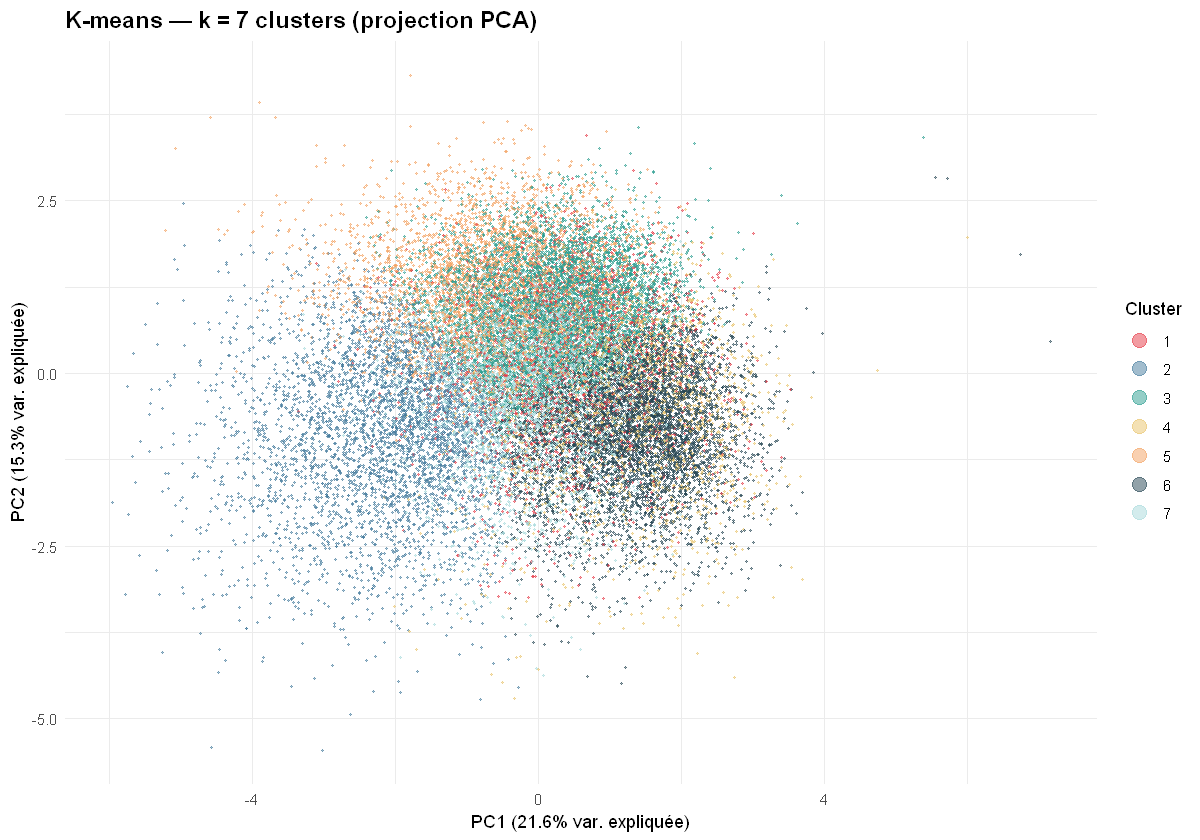

In [95]:
# ── Visualisation 2D (projection PCA) ────────────────────────────────────────
pca2    <- PCA(df_scaled, ncp = 7, graph = FALSE)
X_pca   <- pca2$ind$coord
var_exp <- pca2$eig[, 2]  # explained variance percentage

df_pca <- data.frame(
  PC1     = X_pca[, 1],
  PC2     = X_pca[, 2],
  cluster = as.factor(labels_km)
)

options(repr.plot.width = 10, repr.plot.height = 7)

ggplot(df_pca, aes(x = PC1, y = PC2, color = cluster)) +
  geom_point(size = 0.5, alpha = 0.5) +
  scale_color_manual(values = PALETTE, name = "Cluster") +
  labs(
    title = sprintf("K-means — k = %d clusters (projection PCA)", k_optimal),
    x     = sprintf("PC1 (%.1f%% var. expliquée)", var_exp[1]),
    y     = sprintf("PC2 (%.1f%% var. expliquée)", var_exp[2])
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(face = "bold", size = 14),
    panel.grid = element_line(alpha = 0.3)
  ) +
  guides(color = guide_legend(override.aes = list(size = 4)))  

## 2. CAH

In [111]:
# ── Sous-échantillonnage ──────────────────────────────────────────────────────
set.seed(42)
n_sub    <- 3000
idx_sub  <- sample(nrow(df_scaled), n_sub, replace = FALSE)
df_sub <- df_scaled[idx_sub, ]

Warning message in element_line(alpha = 0.4):
"`...` must be empty.
✖ Problematic argument:
• alpha = 0.4"


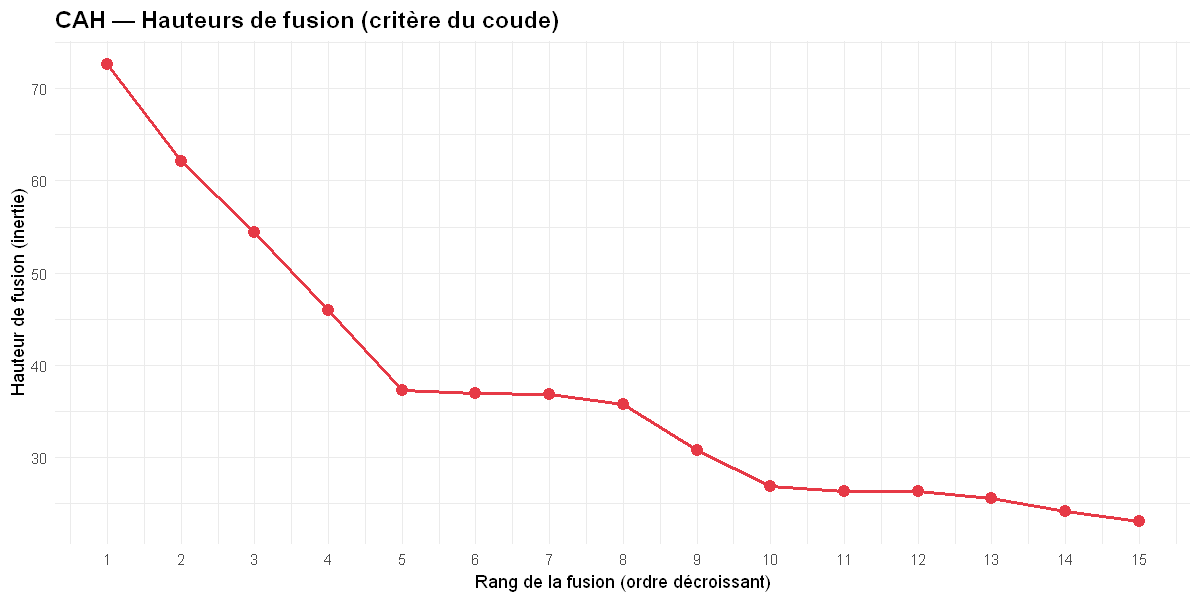

In [ ]:
# ── Calcul de la liaison (Ward) et hauteurs de fusion ────────────────────────
hac     <- hclust(dist(df_sub), method = "ward.D2")

# Les 15 dernières hauteurs de fusion (ordre décroissant)
hauteurs <- sort(hac$height, decreasing = TRUE)[1:15]

df_haut <- data.frame(
  rang    = 1:15,
  hauteur = hauteurs
)

options(repr.plot.width = 10, repr.plot.height = 5)

ggplot(df_haut, aes(x = rang, y = hauteur)) +
  geom_line(color = "#E63946", linewidth = 1) +
  geom_point(color = "#E63946", size = 3) +
  scale_x_continuous(breaks = 1:15) +
  labs(
    title = "CAH — Hauteurs de fusion (critère du coude)",
    x     = "Rang de la fusion (ordre décroissant)",
    y     = "Hauteur de fusion (inertie)"
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(face = "bold", size = 14),
    panel.grid = element_line(alpha = 0.4)
  )

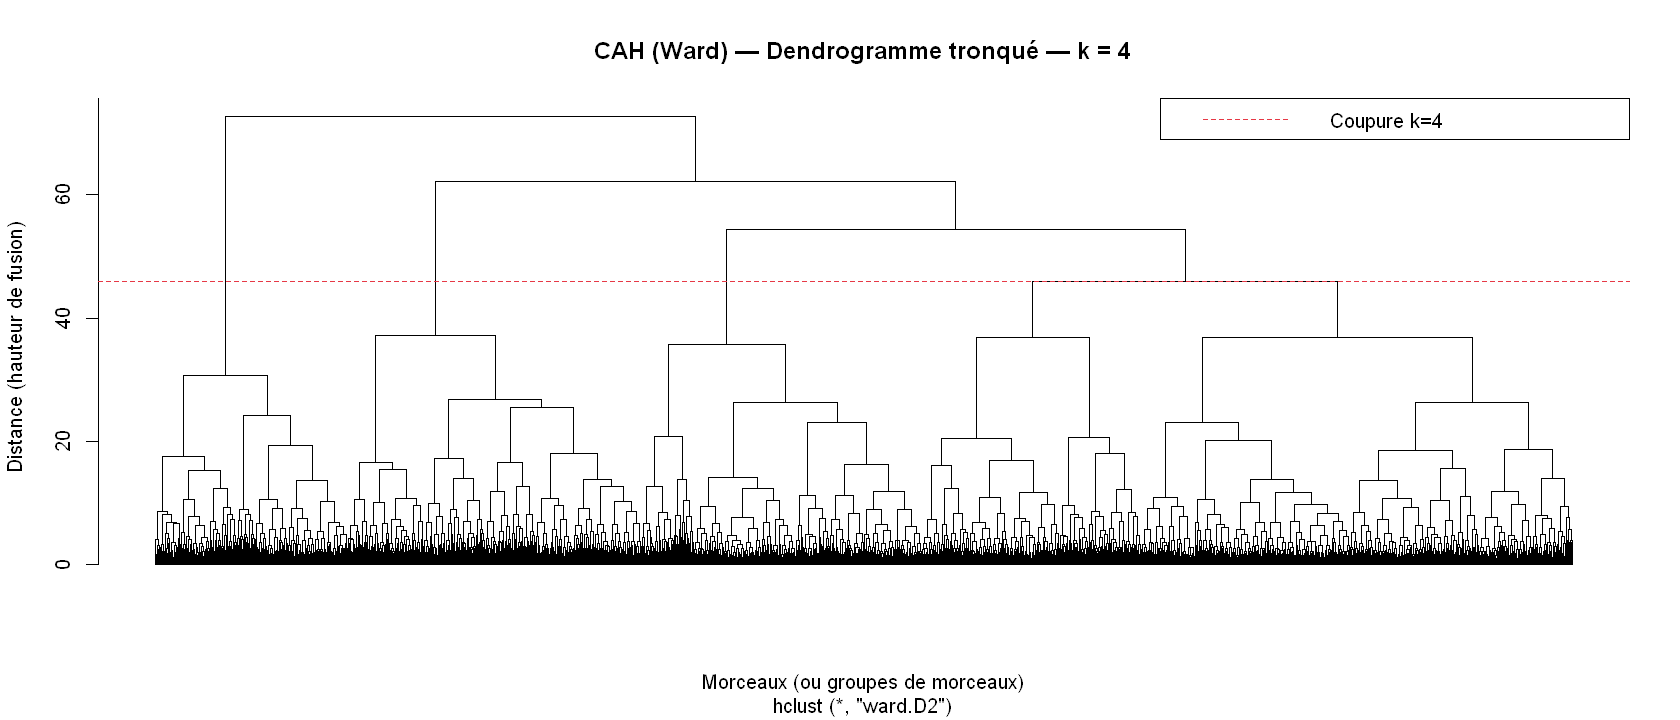

In [116]:
# ── Dendrogramme (tronqué pour lisibilité) ────────────────────────────────────
k_sub <- 4  # à ajuster d'après le graphe ci-dessus

# Coupure threshold (equivalent de Z[-k_hac, 2])
cut_height <- sort(df_haut$hauteur, decreasing = TRUE)[k_sub]

options(repr.plot.width = 14, repr.plot.height = 6)

# Base R dendrogram (plus simple et fidèle au Python)
plot(hac,
     hang        = -1,
     labels      = FALSE,      # cache les labels pour lisibilité
     main        = sprintf("CAH (Ward) — Dendrogramme tronqué — k = %d", k_sub),
     xlab        = "Morceaux (ou groupes de morceaux)",
     ylab        = "Distance (hauteur de fusion)",
     cex.main    = 1.2)

# Ligne de coupure
abline(h = cut_height, col = "#E63946", lty = 2, lwd = 1.5)
legend("topright",
       legend = sprintf("Coupure k=%d", k_sub),
       col    = "#E63946",
       lty    = 2,
       lwd    = 1.5)

Score silhouette moyen CAH : 0.0731
Taille des clusters        : 593 1377 408 622 


Warning message in element_line(alpha = 0.4):
"`...` must be empty.
✖ Problematic argument:
• alpha = 0.4"


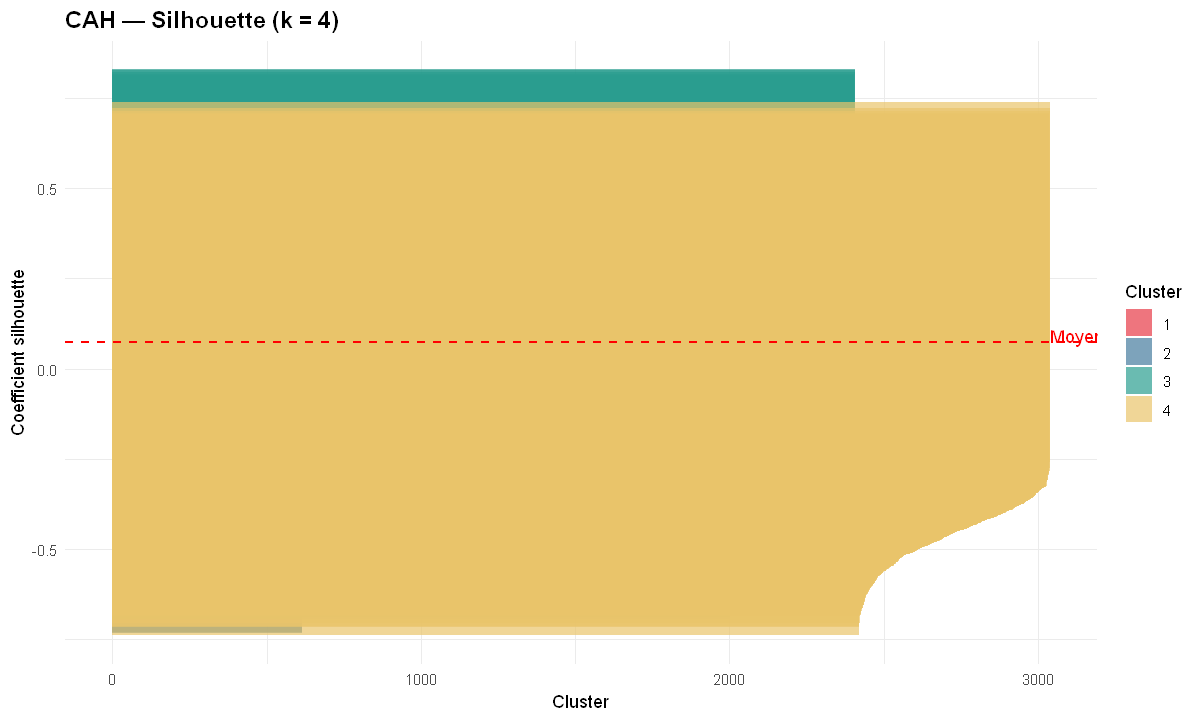

In [117]:
# ── Découpe de l'arbre et silhouette ─────────────────────────────────────────
clusters_sub <- cutree(hac, k = k_sub)

sil_obj      <- silhouette(clusters_sub, dist(df_sub))
sil_vals_hac <- sil_obj[, 3]
sil_avg_hac  <- mean(sil_vals_hac)

cat(sprintf("Score silhouette moyen CAH : %.4f\n", sil_avg_hac))
cat("Taille des clusters        :", table(clusters_sub), "\n")

# ── Silhouette plot ───────────────────────────────────────────────────────────
df_sil <- data.frame(
  cluster = as.factor(clusters_sub),
  sil_val = sil_vals_hac
)

df_sil <- df_sil[order(df_sil$cluster, df_sil$sil_val), ]
df_sil$y <- seq_len(nrow(df_sil))

# Add gaps between clusters
gap          <- 10
df_sil$y_gap <- df_sil$y + as.integer(df_sil$cluster) * gap

options(repr.plot.width = 10, repr.plot.height = 6)

ggplot(df_sil, aes(x = sil_val, y = y_gap, fill = cluster)) +
  geom_col(width = 1, alpha = 0.7) +
  geom_vline(xintercept = sil_avg_hac, color = "red", linetype = "dashed",
             linewidth = 0.8) +
  annotate("text", x = sil_avg_hac + 0.02, y = max(df_sil$y_gap),
           label = sprintf("Moyenne = %.3f", sil_avg_hac), color = "red", hjust = 0) +
  scale_fill_manual(values = PALETTE, name = "Cluster") +
  labs(
    title = sprintf("CAH — Silhouette (k = %d)", k_hac),
    x     = "Coefficient silhouette",
    y     = "Cluster"
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(face = "bold", size = 14),
    panel.grid = element_line(alpha = 0.4)
  ) +
  coord_flip()

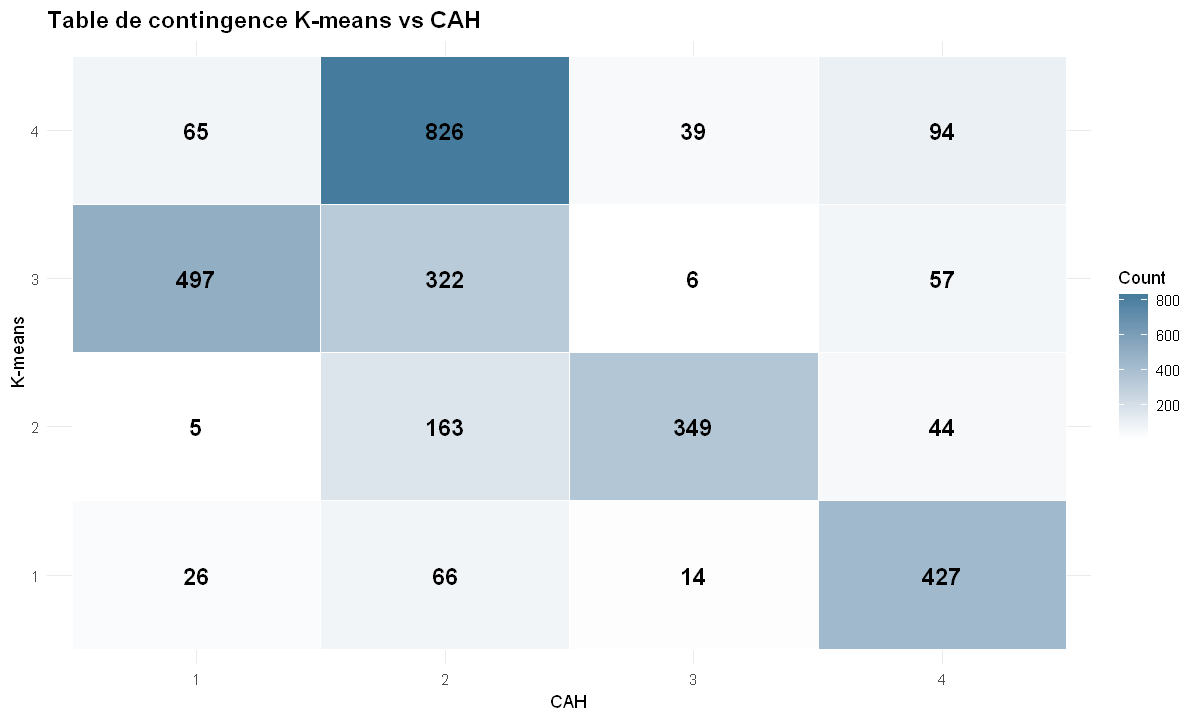

In [ ]:
# ── Comparaison K-means vs CAH (sur le sous-échantillon HAC) ─────────────────
km <- kmeans(df_scaled, centers = 4, nstart = 25, iter.max = 300)
labels_km <- km$cluster
labels_km_sub <- labels_km[idx_sub]

ct <- table("K-means" = labels_km_sub, "CAH" = clusters_sub)
df_ct <- as.data.frame(ct)

ggplot(df_ct, aes(x = CAH, y = K.means, fill = Freq)) +
  geom_tile(color = "white") +
  geom_text(aes(label = Freq), size = 5, fontface = "bold") +
  scale_fill_gradient(low = "white", high = "#457B9D") +
  labs(
    title = "Table de contingence K-means vs CAH",
    x     = "CAH",
    y     = "K-means",
    fill  = "Count"
  ) +
  theme_minimal() +
  theme(plot.title = element_text(face = "bold", size = 14))

## 3. Spectral Clustering

Warning message in element_line(alpha = 0.4):
"`...` must be empty.
✖ Problematic argument:
• alpha = 0.4"


k optimal (eigengap) : 5


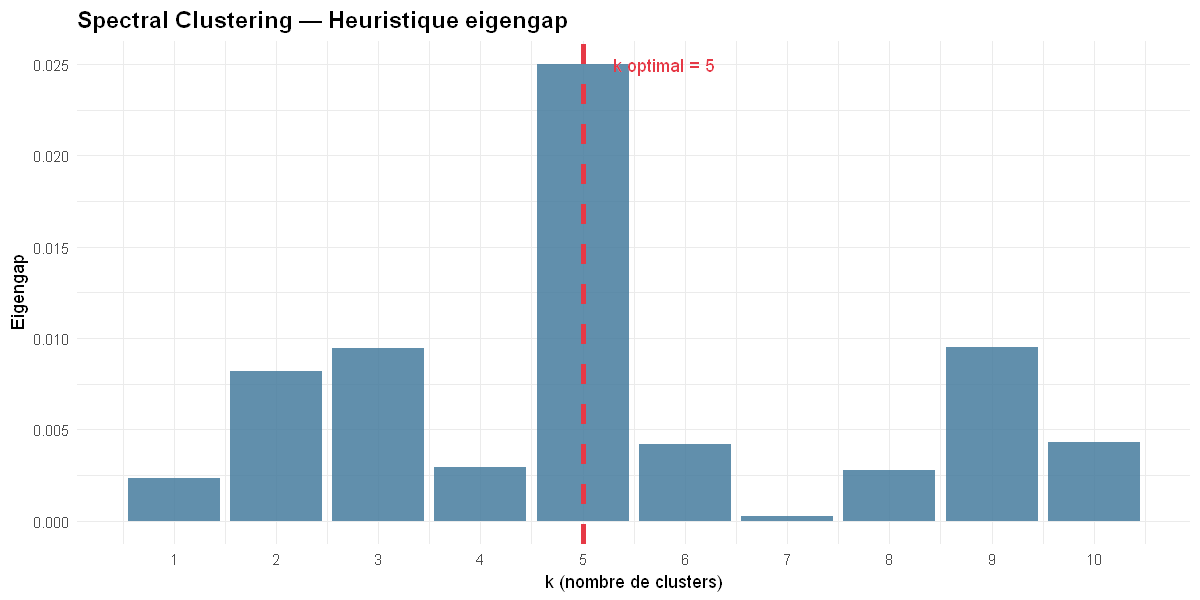

In [112]:
# Heuristique eigengap 
sigma_val <- 1.0

# Matrice de similarité Gaussienne (RBF)
dist_sc_mat <- as.matrix(dist(df_sub, method = "euclidean"))
K_sim       <- exp(-dist_sc_mat^2 / (2 * sigma_val^2))

# Laplacien normalisé symétrique : L = D^{-1/2} K D^{-1/2}
d          <- rowSums(K_sim)
D_inv_sqrt <- diag(1.0 / sqrt(d))
L_norm     <- D_inv_sqrt %*% K_sim %*% D_inv_sqrt

# Valeurs propres (ordre décroissant)
eig_vals <- sort(eigen(L_norm, symmetric = TRUE, only.values = TRUE)$values,
                 decreasing = TRUE)

k_max_sc  <- 10
eigengap  <- -diff(eig_vals[1:(k_max_sc + 1)])  # négatif → on cherche le max
k_sc      <- which.max(eigengap)

df_eig <- data.frame(
  k        = 1:k_max_sc,
  eigengap = eigengap
)

options(repr.plot.width = 10, repr.plot.height = 5)

ggplot(df_eig, aes(x = k, y = eigengap)) +
  geom_col(fill = "#457B9D", alpha = 0.85) +
  geom_vline(xintercept = k_sc, color = "#E63946", linetype = "dashed",
             linewidth = 1.5) +
  annotate("text", x = k_sc + 0.3, y = max(eigengap),
           label = sprintf("k optimal = %d", k_sc), color = "#E63946", hjust = 0) +
  scale_x_continuous(breaks = 1:k_max_sc) +
  labs(
    title = "Spectral Clustering — Heuristique eigengap",
    x     = "k (nombre de clusters)",
    y     = "Eigengap"
  ) +
  theme_minimal() +
  theme(
    plot.title  = element_text(face = "bold", size = 14),
    panel.grid  = element_line(alpha = 0.4)
  )

cat(sprintf("k optimal (eigengap) : %d\n", k_sc))

In [118]:
# ── Ajustement Spectral Clustering ────────────────────────────────────────────
# rbfdot : noyau gaussien
# centers : k-means dans l'espace spectral

set.seed(42)
sub <- specc(df_sub,
            centers = k_sub,
            kernel  = "rbfdot",
            kpar    = list(sigma = 1.0 / (2 * sigma_val^2)))

clusters_sc <- as.integer(sub)

cat("Taille des clusters :", table(clusters_sc), "\n")

Taille des clusters : 838 682 1005 475 


Score silhouette moyen : 0.0731


Warning message in element_line(alpha = 0.4):
"`...` must be empty.
✖ Problematic argument:
• alpha = 0.4"


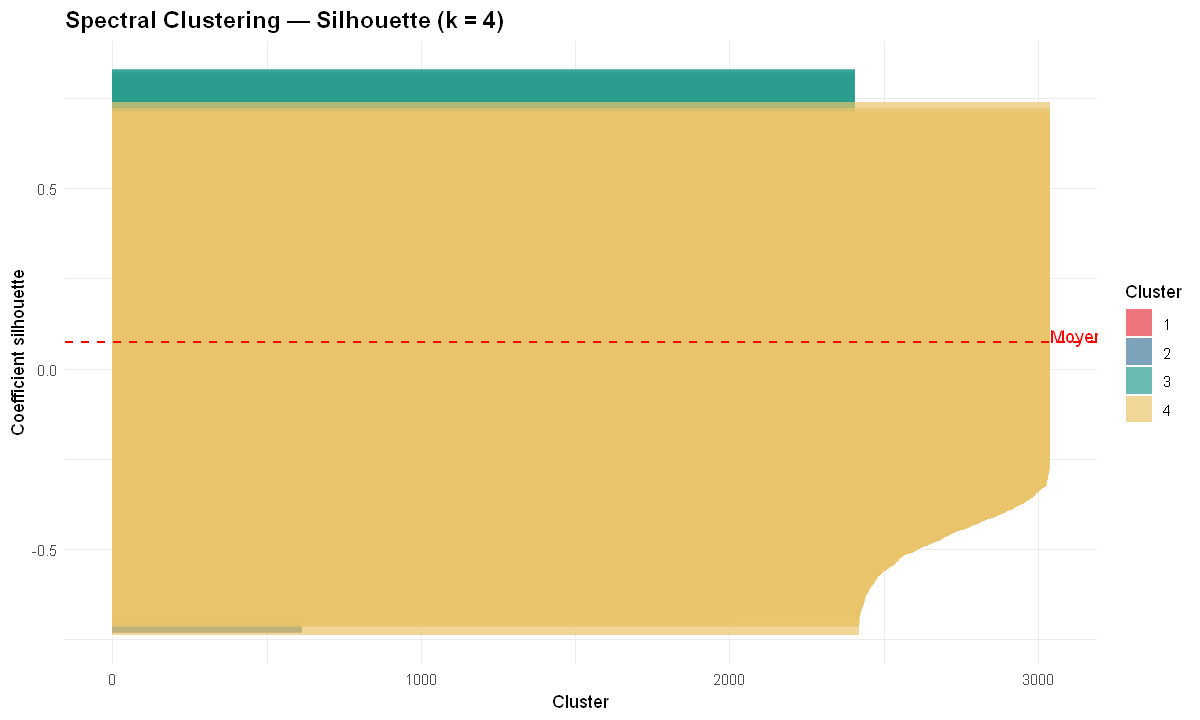

In [122]:
# ── Silhouette Spectral Clustering ───────────────────────────────────────────
sil_obj     <- silhouette(clusters_sub, dist(df_sub))
sil_vals_sub <- sil_obj[, 3]
sil_avg_sub  <- mean(sil_vals_sub)

cat(sprintf("Score silhouette moyen : %.4f\n", sil_avg_sub))

# ── Silhouette plot ───────────────────────────────────────────────────────────
df_sil <- data.frame(
  cluster = as.factor(clusters_sub),
  sil_val = sil_vals_sub
)

df_sil       <- df_sil[order(df_sil$cluster, df_sil$sil_val), ]
df_sil$y     <- seq_len(nrow(df_sil))
gap          <- 10
df_sil$y_gap <- df_sil$y + as.integer(df_sil$cluster) * gap

options(repr.plot.width = 10, repr.plot.height = 6)

ggplot(df_sil, aes(x = sil_val, y = y_gap, fill = cluster)) +
  geom_col(width = 1, alpha = 0.7) +
  geom_vline(xintercept = sil_avg_sub, color = "red", linetype = "dashed",
             linewidth = 0.8) +
  annotate("text", x = sil_avg_sub + 0.02, y = max(df_sil$y_gap),
           label = sprintf("Moyenne = %.3f", sil_avg_sub), color = "red", hjust = 0) +
  scale_fill_manual(values = PALETTE, name = "Cluster") +
  labs(
    title = sprintf("Spectral Clustering — Silhouette (k = %d)", k_sub),
    x     = "Coefficient silhouette",
    y     = "Cluster"
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(face = "bold", size = 14),
    panel.grid = element_line(alpha = 0.4)
  ) +
  coord_flip()

Warning message in element_line(alpha = 0.3):
"`...` must be empty.
✖ Problematic argument:
• alpha = 0.3"


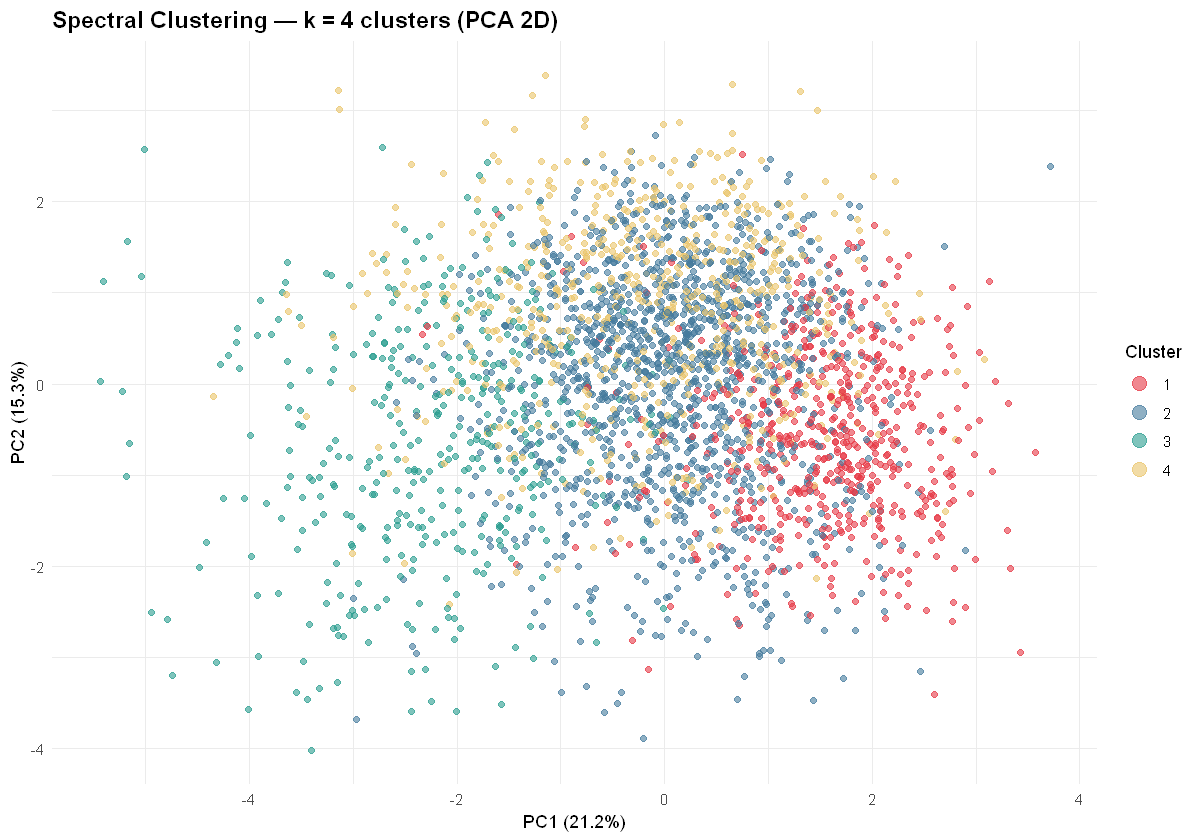

In [123]:
# ── Visualisation 2D (PCA) ────────────────────────────────────────────────────
pca_sc  <- PCA(df_sub, ncp = 2, graph = FALSE)
X_sc_2d <- pca_sc$ind$coord
var_exp <- pca_sc$eig[, 2]

df_pca <- data.frame(
  PC1     = X_sc_2d[, 1],
  PC2     = X_sc_2d[, 2],
  cluster = as.factor(clusters_sub)
)

options(repr.plot.width = 10, repr.plot.height = 7)

ggplot(df_pca, aes(x = PC1, y = PC2, color = cluster)) +
  geom_point(size = 1.5, alpha = 0.6) +
  scale_color_manual(values = PALETTE, name = "Cluster") +
  labs(
    title = sprintf("Spectral Clustering — k = %d clusters (PCA 2D)", k_sub),
    x     = sprintf("PC1 (%.1f%%)", var_exp[1]),
    y     = sprintf("PC2 (%.1f%%)", var_exp[2])
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(face = "bold", size = 14),
    panel.grid = element_line(alpha = 0.3)
  ) +
  guides(color = guide_legend(override.aes = list(size = 4)))

## 4. DBSCAN

Warning message in element_line(alpha = 0.4):
"`...` must be empty.
✖ Problematic argument:
• alpha = 0.4"


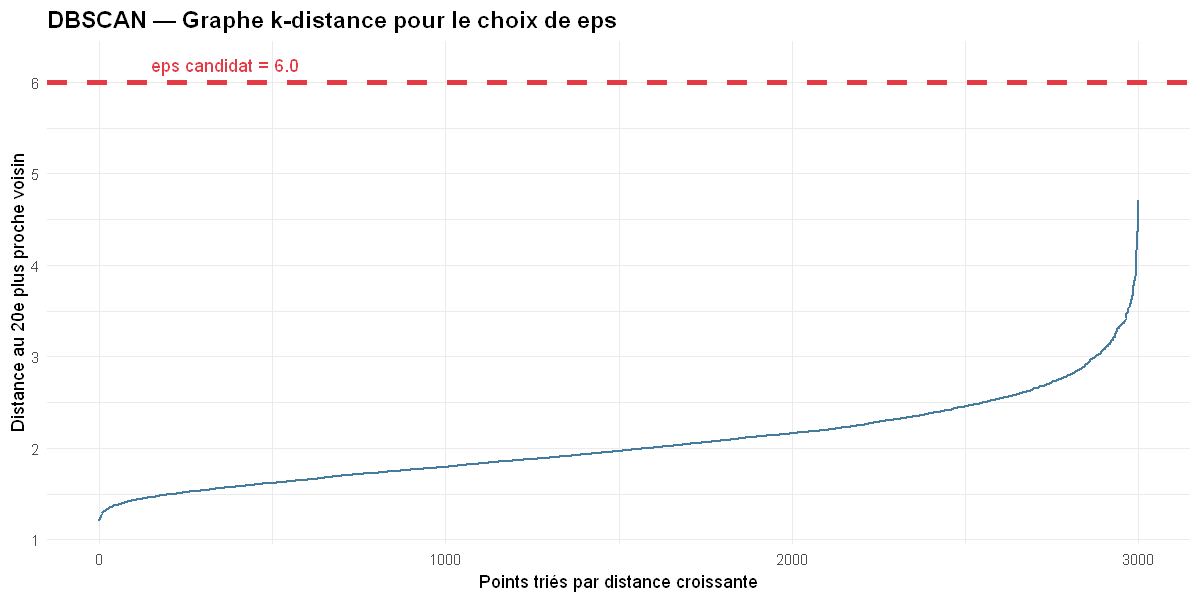

In [125]:
# ── Choix de eps : graphe k-distance ─────────────────────────────────────────
min_samples_val <- ncol(df_sub) * 2   # règle empirique : 2 × dimension

# Calcul des k plus proches voisins
knn     <- kNN(df_sub, k = min_samples_val)
k_dist  <- sort(knn$dist[, min_samples_val])  # distance au k-ième voisin, triée

eps_candidat <- 6.0

df_kdist <- data.frame(
  x      = seq_along(k_dist),
  k_dist = k_dist
)

options(repr.plot.width = 10, repr.plot.height = 5)

ggplot(df_kdist, aes(x = x, y = k_dist)) +
  geom_line(color = "#457B9D", linewidth = 0.8) +
  geom_hline(yintercept = eps_candidat, color = "#E63946", linetype = "dashed",
             linewidth = 1.5) +
  annotate("text", x = nrow(df_kdist) * 0.05, y = eps_candidat + 0.2,
           label = sprintf("eps candidat = %.1f", eps_candidat),
           color = "#E63946", hjust = 0) +
  labs(
    title = "DBSCAN — Graphe k-distance pour le choix de eps",
    x     = "Points triés par distance croissante",
    y     = sprintf("Distance au %de plus proche voisin", min_samples_val)
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(face = "bold", size = 14),
    panel.grid = element_line(alpha = 0.4)
  )

In [136]:
# ── Ajustement DBSCAN ─────────────────────────────────────────────────────────
eps_val <- 1.5   # à ajuster d'après le graphe k-distance ci-dessus

db          <- dbscan(df_sub, eps = eps_val, minPts = min_samples_val)
clusters_db <- db$cluster   # 0 = bruit (instead of -1 in Python)

n_clusters_db <- length(unique(clusters_db[clusters_db != 0]))
n_noise       <- sum(clusters_db == 0)

cat(sprintf("Nombre de clusters : %d\n", n_clusters_db))
cat(sprintf("Points de bruit    : %d (%.1f%%)\n", n_noise, n_noise / nrow(df_sub) * 100))
cat("Taille clusters    :", table(clusters_db), "\n")

Nombre de clusters : 2
Points de bruit    : 2093 (69.8%)
Taille clusters    : 2093 898 9 


Warning message in element_line(alpha = 0.3):
"`...` must be empty.
✖ Problematic argument:
• alpha = 0.3"


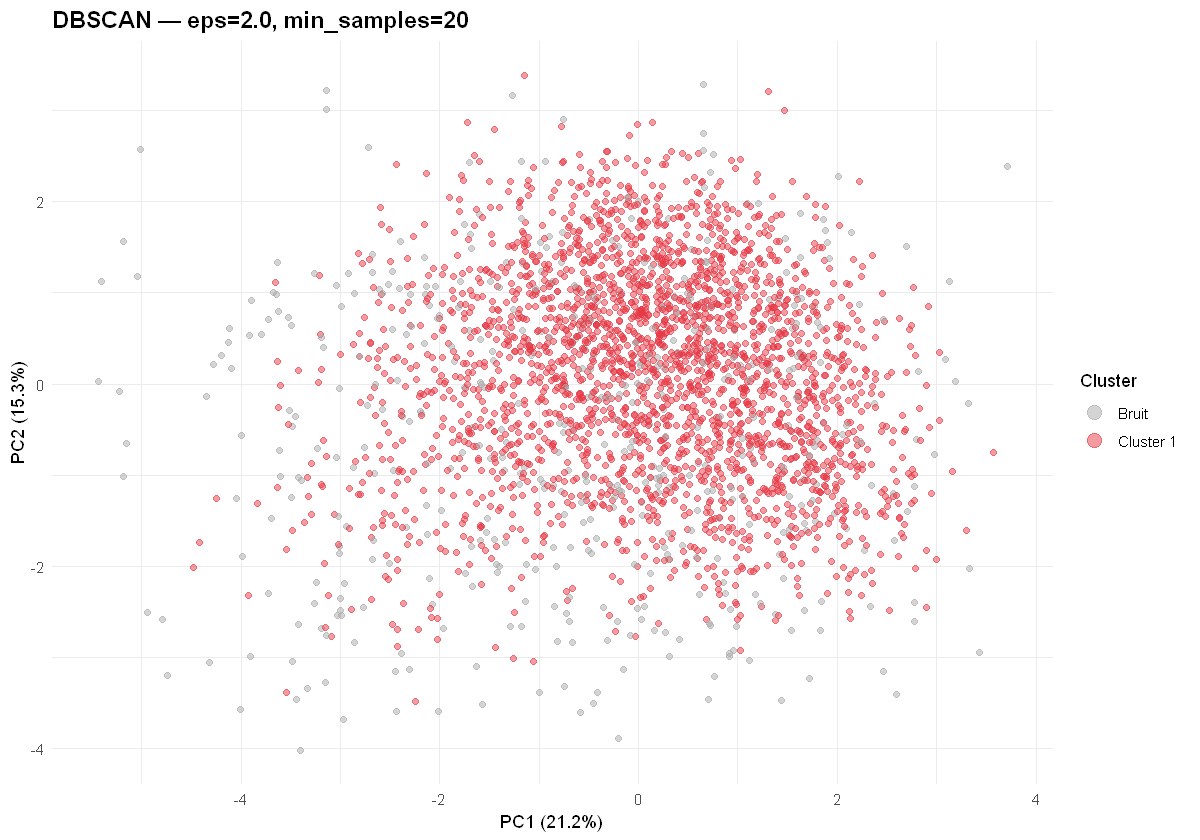

In [134]:
# ── Visualisation 2D (PCA) ────────────────────────────────────────────────────
pca_db  <- PCA(df_sub, ncp = 2, graph = FALSE)
X_db_2d <- pca_db$ind$coord
var_exp <- pca_db$eig[, 2]

# Gris pour le bruit (0), PALETTE pour les clusters
pal_db <- c("0" = "#aaaaaa")
for (i in seq_len(n_clusters_db)) {
  pal_db[as.character(i)] <- PALETTE[i]
}

df_pca <- data.frame(
  PC1     = X_db_2d[, 1],
  PC2     = X_db_2d[, 2],
  cluster = as.factor(clusters_db)
)

# Labels lisibles
cluster_labels <- c("0" = "Bruit")
for (i in seq_len(n_clusters_db)) {
  cluster_labels[as.character(i)] <- sprintf("Cluster %d", i)
}

options(repr.plot.width = 10, repr.plot.height = 7)

ggplot(df_pca, aes(x = PC1, y = PC2, color = cluster)) +
  geom_point(size = 1.5, alpha = 0.5) +
  scale_color_manual(values  = pal_db,
                     labels  = cluster_labels,
                     name    = "Cluster") +
  labs(
    title = sprintf("DBSCAN — eps=%.1f, min_samples=%d", eps_val, min_samples_val),
    x     = sprintf("PC1 (%.1f%%)", var_exp[1]),
    y     = sprintf("PC2 (%.1f%%)", var_exp[2])
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(face = "bold", size = 14),
    panel.grid = element_line(alpha = 0.3)
  ) +
  guides(color = guide_legend(override.aes = list(size = 4)))

Score silhouette moyen (sans bruit) : 0.1684
Points classés : 907 / 3000


Warning message in element_line(alpha = 0.4):
"`...` must be empty.
✖ Problematic argument:
• alpha = 0.4"


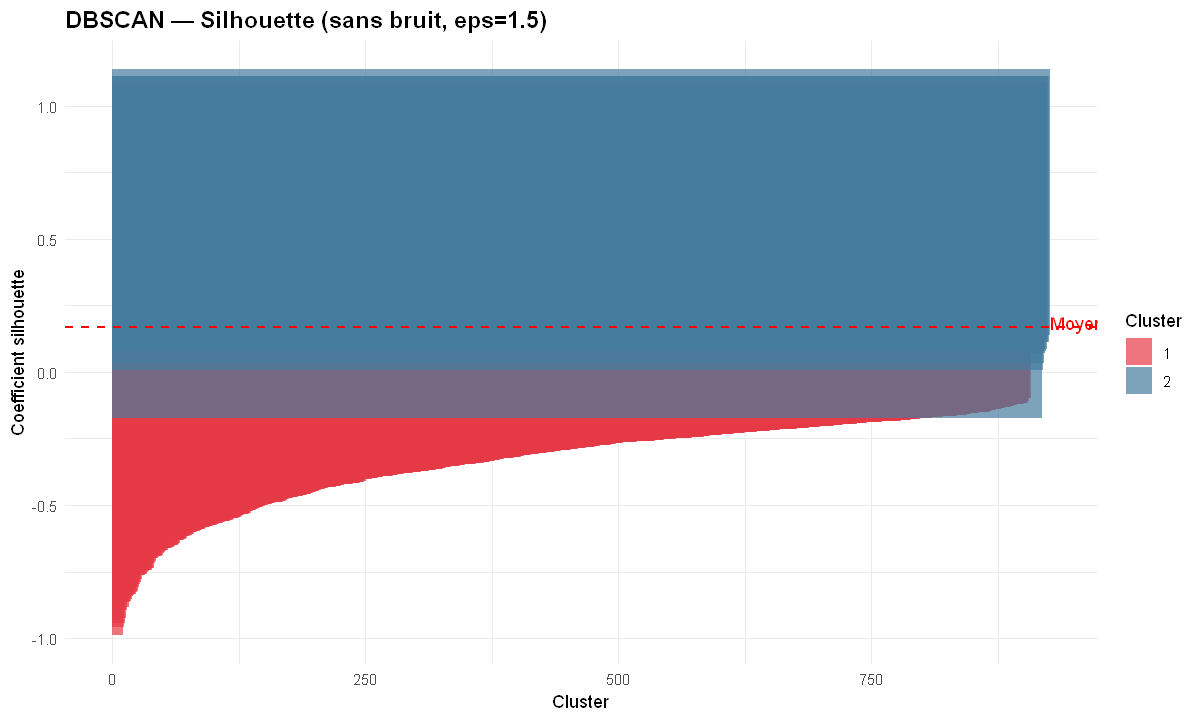

In [137]:
# ── Silhouette DBSCAN (sans les points de bruit) ─────────────────────────────
mask_core    <- clusters_db != 0   # 0 = bruit en R 
data_core    <- df_sub[mask_core, ]
clusters_core <- clusters_db[mask_core]

if (sum(mask_core) > 1 && length(unique(clusters_core)) > 1) {

  sil_obj     <- silhouette(clusters_core, dist(data_core))
  sil_vals_db <- sil_obj[, 3]
  sil_avg_db  <- mean(sil_vals_db)

  cat(sprintf("Score silhouette moyen (sans bruit) : %.4f\n", sil_avg_db))
  cat(sprintf("Points classés : %d / %d\n", sum(mask_core), nrow(df_sub)))

  # ── Silhouette plot ─────────────────────────────────────────────────────────
  df_sil <- data.frame(
    cluster = as.factor(clusters_core),
    sil_val = sil_vals_db
  )

  df_sil       <- df_sil[order(df_sil$cluster, df_sil$sil_val), ]
  df_sil$y     <- seq_len(nrow(df_sil))
  gap          <- 10
  df_sil$y_gap <- df_sil$y + as.integer(df_sil$cluster) * gap

  options(repr.plot.width = 10, repr.plot.height = 6)

  print(
    ggplot(df_sil, aes(x = sil_val, y = y_gap, fill = cluster)) +
      geom_col(width = 1, alpha = 0.7) +
      geom_vline(xintercept = sil_avg_db, color = "red", linetype = "dashed",
                 linewidth = 0.8) +
      annotate("text", x = sil_avg_db + 0.02, y = max(df_sil$y_gap),
               label = sprintf("Moyenne = %.3f", sil_avg_db), color = "red", hjust = 0) +
      scale_fill_manual(values = PALETTE, name = "Cluster") +
      labs(
        title = sprintf("DBSCAN — Silhouette (sans bruit, eps=%.1f)", eps_val),
        x     = "Coefficient silhouette",
        y     = "Cluster"
      ) +
      theme_minimal() +
      theme(
        plot.title = element_text(face = "bold", size = 14),
        panel.grid = element_line(alpha = 0.4)
      ) +
      coord_flip()
  )

} else {
  cat("Silhouette non calculable : trop peu de clusters ou tous les points sont du bruit.\n")
  cat("Essayez d'augmenter eps ou de réduire min_samples.\n")
  sil_avg_db <- NA
}

## 5. GMM

Warning message in element_line(alpha = 0.4):
"`...` must be empty.
✖ Problematic argument:
• alpha = 0.4"


Modèle optimal : covariance='VVV', G=7


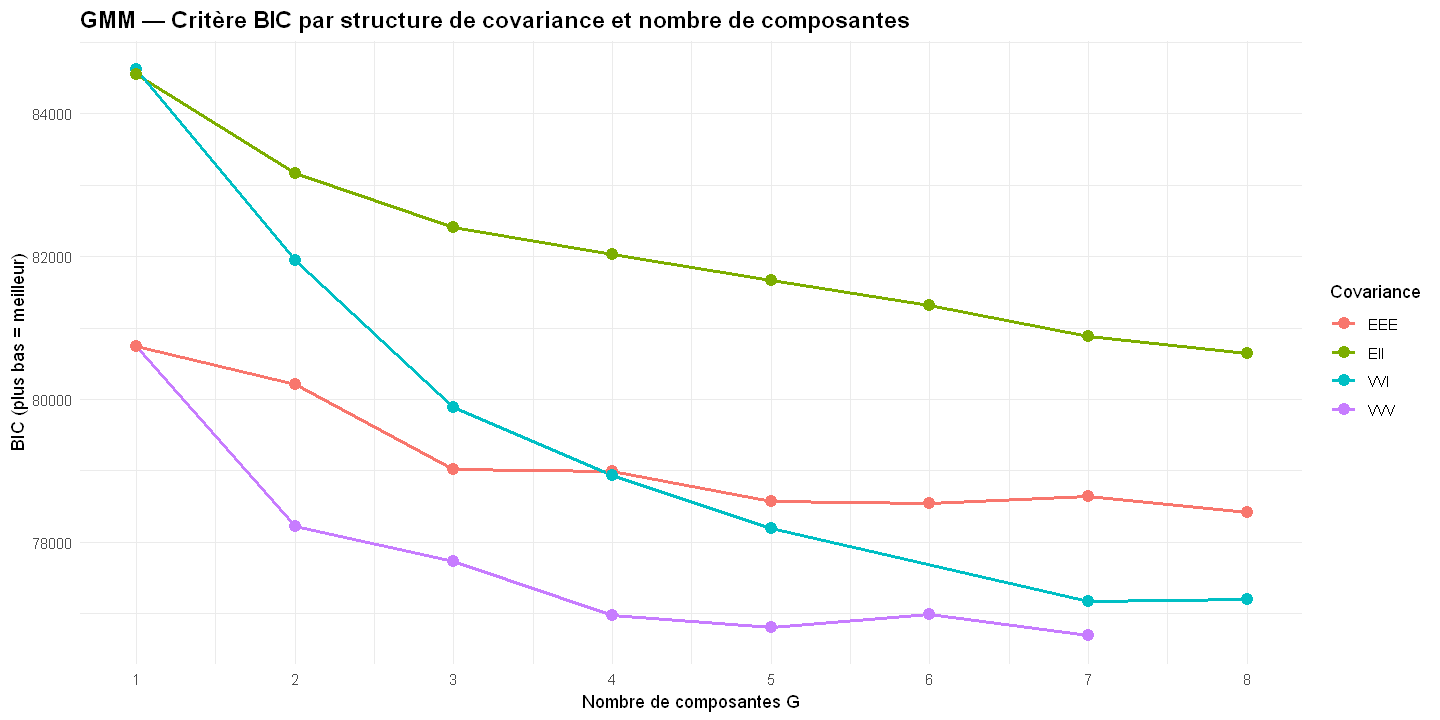

In [140]:
# ── Sélection de G et de la structure de covariance via BIC ──────────────────

G_range   <- 1:8
cov_types <- c("VVV", "EEE", "VVI", "EII")

bic_results <- data.frame()

for (cov in cov_types) {
  for (g in G_range) {
    gmm_tmp <- Mclust(df_sub, G = g, modelNames = cov, verbose = FALSE)
    if (!is.null(gmm_tmp)) {
      bic_results <- rbind(bic_results, data.frame(
        cov = cov,
        g   = g,
        bic = -gmm_tmp$bic   # mclust maximizes BIC, negate to match Python (minimize)
      ))
    }
  }
}

options(repr.plot.width = 12, repr.plot.height = 6)

ggplot(bic_results, aes(x = g, y = bic, color = cov, group = cov)) +
  geom_line(linewidth = 1) +
  geom_point(size = 3) +
  scale_x_continuous(breaks = G_range) +
  labs(
    title  = "GMM — Critère BIC par structure de covariance et nombre de composantes",
    x      = "Nombre de composantes G",
    y      = "BIC (plus bas = meilleur)",
    color  = "Covariance"
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(face = "bold", size = 14),
    panel.grid = element_line(alpha = 0.4)
  )

# Modèle optimal : BIC minimal
best_row <- bic_results[which.min(bic_results$bic), ]
best_cov <- best_row$cov
best_g   <- best_row$g
cat(sprintf("Modèle optimal : covariance='%s', G=%d\n", best_cov, best_g))

In [141]:
# ── Ajustement du modèle optimal ─────────────────────────────────────────────
set.seed(42)
gmm <- Mclust(df_sub, G = best_g, modelNames = best_cov, verbose = FALSE)

clusters_gmm <- gmm$classification
proba_gmm    <- gmm$z                          # matrice de probabilités d'appartenance
uncertainty  <- 1 - apply(proba_gmm, 1, max)  # incertitude = 1 - proba max

cat(sprintf("BIC                    : %.2f\n",  -gmm$bic))
cat(sprintf("Log-vraisemblance      : %.4f\n",   gmm$loglik))
cat("Taille des composantes :", table(clusters_gmm), "\n")
cat(sprintf("Incertitude moyenne    : %.4f\n",   mean(uncertainty)))

BIC                    : 76980.84
Log-vraisemblance      : -36644.9525
Taille des composantes : 383 438 696 359 351 480 293 
Incertitude moyenne    : 0.1742


Score silhouette moyen : 0.0095


Warning message in element_line(alpha = 0.4):
"`...` must be empty.
✖ Problematic argument:
• alpha = 0.4"


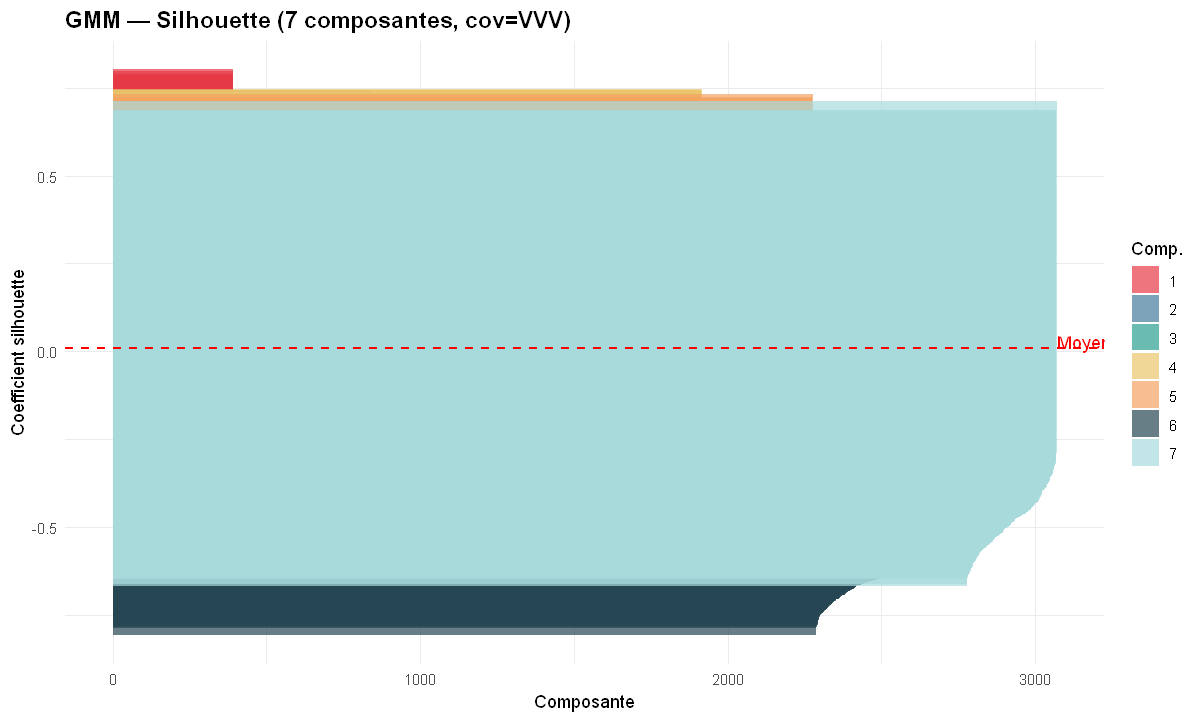

In [143]:
# ── Silhouette GMM ────────────────────────────────────────────────────────────
sil_obj      <- silhouette(clusters_gmm, dist(df_sub))
sil_vals_gmm <- sil_obj[, 3]
sil_avg_gmm  <- mean(sil_vals_gmm)

cat(sprintf("Score silhouette moyen : %.4f\n", sil_avg_gmm))

# ── Silhouette plot ───────────────────────────────────────────────────────────
df_sil <- data.frame(
  cluster = as.factor(clusters_gmm),
  sil_val = sil_vals_gmm
)

df_sil       <- df_sil[order(df_sil$cluster, df_sil$sil_val), ]
df_sil$y     <- seq_len(nrow(df_sil))
gap          <- 10
df_sil$y_gap <- df_sil$y + as.integer(df_sil$cluster) * gap

options(repr.plot.width = 10, repr.plot.height = 6)

print(
  ggplot(df_sil, aes(x = sil_val, y = y_gap, fill = cluster)) +
    geom_col(width = 1, alpha = 0.7) +
    geom_vline(xintercept = sil_avg_gmm, color = "red", linetype = "dashed",
               linewidth = 0.8) +
    annotate("text", x = sil_avg_gmm + 0.02, y = max(df_sil$y_gap),
             label = sprintf("Moyenne = %.3f", sil_avg_gmm), color = "red", hjust = 0) +
    scale_fill_manual(values = PALETTE, name = "Comp.") +
    labs(
      title = sprintf("GMM — Silhouette (%d composantes, cov=%s)", best_g, best_cov),
      x     = "Coefficient silhouette",
      y     = "Composante"
    ) +
    theme_minimal() +
    theme(
      plot.title = element_text(face = "bold", size = 14),
      panel.grid = element_line(alpha = 0.4)
    ) +
    coord_flip()
)

Warning message in element_line(alpha = 0.3):
"`...` must be empty.
✖ Problematic argument:
• alpha = 0.3"


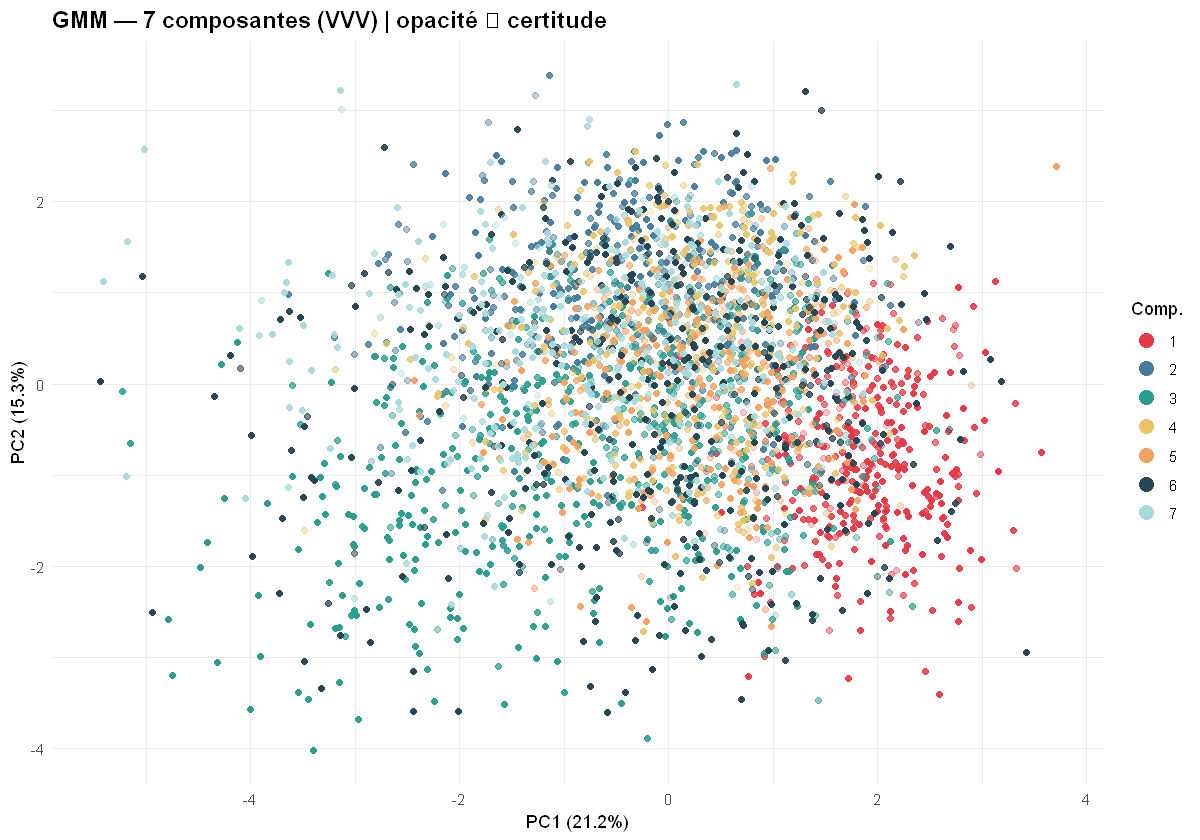

In [145]:
# ── Visualisation 2D (PCA) — opacité ∝ certitude ─────────────────────────────
pca_gmm  <- PCA(df_sub, ncp = 2, graph = FALSE)
X_gmm_2d <- pca_gmm$ind$coord
var_exp  <- pca_gmm$eig[, 2]

df_pca <- data.frame(
  PC1       = X_gmm_2d[, 1],
  PC2       = X_gmm_2d[, 2],
  cluster   = as.factor(clusters_gmm),
  certainty = 1 - uncertainty   # opacité ∝ certitude
)

options(repr.plot.width = 10, repr.plot.height = 7)

# Plot each cluster separately to allow per-point alpha
plots <- lapply(seq_len(best_g), function(i) {
  df_i <- df_pca[df_pca$cluster == i, ]
  geom_point(data = df_i,
             aes(x = PC1, y = PC2, color = cluster, alpha = certainty),
             size = 1.5, show.legend = TRUE)
})

p <- ggplot(df_pca) +
  plots +
  scale_color_manual(values = setNames(PALETTE[seq_len(best_g)],
                                       as.character(seq_len(best_g))),
                     name   = "Comp.") +
  scale_alpha_continuous(range = c(0.1, 1.0), guide = "none") +
  labs(
    title = sprintf("GMM — %d composantes (%s) | opacité ∝ certitude", best_g, best_cov),
    x     = sprintf("PC1 (%.1f%%)", var_exp[1]),
    y     = sprintf("PC2 (%.1f%%)", var_exp[2])
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(face = "bold", size = 14),
    panel.grid = element_line(alpha = 0.3)
  ) +
  guides(color = guide_legend(override.aes = list(size = 4, alpha = 1)))

print(p)